# Distributions by size quintile

Companion to `descriptive_figures.ipynb`. That notebook splits banks into the top 1% and everyone else and shows 1-, 2- and 3-quarter changes. This one follows the revised design:

- **Size quintiles instead of top 1% vs rest.** Each quarter, banks are ranked by total assets and split into five groups of 20 percentiles: Q1 is the smallest fifth and Q5 the largest. Each group has hundreds to thousands of banks, so its tails are no longer set by a handful of institutions.
- **One horizon only.** The lagged (k = 2, 3) displays are dropped; every change is the one-quarter change from *t*−1 to *t*.
- **Ranking on assets at *t*−1.** Group membership uses size at the start of the quarter, so it is predetermined with respect to the change. This removes the selection-on-growth problem that grouping on current assets creates (a bank that jumps into the top group by acquisition is not mechanically a large bank with a large change).
- **Kernel density estimates** of the empirical distributions, by quintile and by business-cycle regime.

Additional figures aimed at the research question: how the cross-sectional distribution shifts with the cycle, and whether that response differs by size.

| Figure | Question it answers |
|---|---|
| Size cutoffs | What do the quintiles mean in dollars, and how have they moved? |
| Fan charts by quintile | How do the median, IQR and 10th–90th range of each quintile move over time? |
| KDE by quintile | How do the full distributions differ across size groups? |
| KDE, expansion vs recession | Within each size group, does the distribution shift, widen, or grow a tail in recessions? |
| Ridgeline by year | How does the whole distribution move year by year through the cycle? |
| Dispersion and skewness over time | Does spread widen and skew turn negative in recessions, and more so for some quintiles? |
| Quantile sensitivity to GDP growth | Which parts of the distribution (lower tail, median, upper tail) co-move with the cycle, by size? This is the descriptive counterpart of the quantile effects in the MLE proposal. |

**Outputs** go to `output/figures/quintiles/` (PDF, PNG, and a caption-ready `_bare.pdf`) and `output/tables/quintile_summary.tex`.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, LogLocator, MaxNLocator

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGS = ROOT / "output" / "figures" / "quintiles"
TABLES = ROOT / "output" / "tables"
FIGS.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

## Figure style

Same style as `descriptive_figures.ipynb`. Size quintiles are ordered, so they take one blue ramp from light (Q1, smallest) to dark (Q5, largest). Expansion versus recession comparisons use the blue/orange pair.

In [2]:
INK = "#1a1a1a"
MUTED = "#6b6b6b"
GRID = "#e3e3e3"
SHADE = "#e6e6e6"
SERIES = ["#2a78d6", "#eb6834"]  # blue, orange
# Ordinal ramp for Q1 (smallest) -> Q5 (largest): blue steps 250, 350, 450, 550, 650
QUINTILE_COLORS = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]

WIDTH, HEIGHT = 6.5, 2.9

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.edgecolor": INK,
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "xtick.color": INK,
    "ytick.color": INK,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "lines.linewidth": 1.4,
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

## Recession dates and shared helpers

NBER peaks and troughs, shaded with FRED's convention (month after the peak through the trough month). A quarter counts as a recession quarter if it overlaps a shaded span.

In [3]:
NBER_CYCLES = [("1990-07", "1991-03"), ("2001-03", "2001-11"), ("2007-12", "2009-06"), ("2020-02", "2020-04")]
RECESSIONS = [((pd.Period(peak, "M") + 1).start_time, pd.Period(trough, "M").end_time)
              for peak, trough in NBER_CYCLES]
X_RANGE = (pd.Timestamp("1992-01-01"), pd.Timestamp("2026-09-30"))


def is_recession_quarter(quarter_end):
    start = quarter_end.to_period("Q").start_time
    return any(start <= r_end and quarter_end >= r_start for r_start, r_end in RECESSIONS)


def shade_recessions(ax):
    for start, end in RECESSIONS:
        ax.axvspan(start, end, color=SHADE, lw=0, zorder=0)


def format_time_axis(ax, xlim=X_RANGE, years_between_ticks=4):
    ax.set_xlim(*xlim)
    ax.xaxis.set_major_locator(mdates.YearLocator(years_between_ticks, month=1, day=1))
    ax.xaxis.set_minor_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", which="minor", length=2)
    ax.grid(False, axis="x")


def add_note(fig, text):
    fig.text(0.0, -0.02, text, ha="left", va="top", fontsize=8, color=MUTED, wrap=True, gid="note")


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(FIGS / f"{name}.{ext}")
    # Caption-ready copy for LaTeX: no in-figure title or note
    extras = [t for t in [*fig.texts, fig._suptitle] if t is not None and t.get_gid() in ("note", "title")]
    for t in extras:
        t.set_visible(False)
    fig.savefig(FIGS / f"{name}_bare.pdf")
    for t in extras:
        t.set_visible(True)
    print(f"saved output/figures/quintiles/{name}.pdf, .png and _bare.pdf")


pct = FuncFormatter(lambda v, _: f"{v:g}%".replace("-", "\u2212"))
signed = FuncFormatter(lambda v, _: f"{v:g}".replace("-", "\u2212"))
SOURCE = "\nSource: FDIC Statistics on Depository Institutions; author's calculations."

## Load the panel

Same sample rules as `descriptive_figures.ipynb`: insured U.S. branches of foreign banks (class `OI`) are dropped, and ratios over a zero denominator (FDIC placeholder zeros) are set to missing.

In [4]:
cols = ["CERT", "REPDTE", "BKCLASS", "ASSET", "EQ", "LNLSNET", "DEP", "ERNASTR", "ROA", "NIMY",
        "NCLNLSR", "NTLNLSR", "ELNATRY", "INTEXPY", "RBC1AAJ"]
panel = pd.read_csv(PROCESSED / "bank_quarter_panel.csv", usecols=cols)
panel = panel.loc[panel["BKCLASS"] != "OI"].drop(columns="BKCLASS")
panel.loc[panel["LNLSNET"] <= 0, ["NCLNLSR", "NTLNLSR"]] = np.nan
panel.loc[panel["ERNASTR"] <= 0, ["NIMY", "INTEXPY"]] = np.nan
panel = panel.loc[panel["ASSET"] > 0].drop(columns="ERNASTR")
panel["date"] = pd.to_datetime(panel["REPDTE"].astype(str), format="%Y%m%d")
print(f"{len(panel):,} bank-quarters, {panel['CERT'].nunique():,} banks, "
      f"{panel['date'].min():%Y-%m-%d} to {panel['date'].max():%Y-%m-%d}")

1,127,856 bank-quarters, 17,121 banks, 1992-03-31 to 2026-06-30


## One-quarter changes and size quintiles

Flow ratios that FDIC reports year-to-date and annualized (ROA, NIM, charge-offs, provisions, cost of funds) are first converted to single-quarter ratios with $r^{q}_{Q} = Q \cdot r^{ytd}_{Q} - (Q-1) \cdot r^{ytd}_{Q-1}$. Each bank is then matched to its own record one quarter earlier:

| Variable | Change measured as |
|---|---|
| Total assets, net loans, total deposits | percent change, $100 \times (X_t / X_{t-1} - 1)$ |
| Equity to assets, Tier 1 leverage, noncurrent loans | percentage-point difference |
| ROA, NIM, net charge-offs, provisions, cost of funds | percentage-point difference in the single-quarter ratio |

Size quintiles are formed within each quarter from total assets at *t*−1, among banks that report in both quarters.

In [5]:
banks = panel.drop(columns="REPDTE").copy()
banks["quarter"] = banks["date"].dt.quarter
banks["equity_ratio"] = banks["EQ"] / banks["ASSET"] * 100
banks = banks.rename(columns={"RBC1AAJ": "leverage", "NCLNLSR": "noncurrent"})


def lagged(df, cols):
    # Same bank's values one quarter-end earlier, keyed to the current date
    out = df[["CERT", "date", *cols]].copy()
    out["date"] = out["date"] + pd.offsets.QuarterEnd(1)
    return out.rename(columns={c: f"{c}_lag" for c in cols})


YTD_RATIOS = {"ROA": "roa", "NIMY": "nim", "NTLNLSR": "chargeoffs", "ELNATRY": "provisions", "INTEXPY": "cost_funds"}
banks = banks.merge(lagged(banks, list(YTD_RATIOS)), on=["CERT", "date"], how="left")
q = banks["quarter"]
for ytd, single in YTD_RATIOS.items():
    banks[single] = np.where(q == 1, banks[ytd], q * banks[ytd] - (q - 1) * banks[f"{ytd}_lag"])
banks = banks.drop(columns=[*YTD_RATIOS, *(f"{ytd}_lag" for ytd in YTD_RATIOS)])

PCT_CHANGE = {"assets": "ASSET", "loans": "LNLSNET", "deposits": "DEP"}
PP_CHANGE = ["equity_ratio", "roa", "nim", "leverage", "noncurrent", "chargeoffs", "provisions", "cost_funds"]
banks = banks.merge(lagged(banks, [*PCT_CHANGE.values(), *PP_CHANGE]), on=["CERT", "date"], how="left")
for name, level in PCT_CHANGE.items():
    base = banks[f"{level}_lag"].where(banks[f"{level}_lag"] > 0)  # no percent change from a zero base
    banks[name + "_chg"] = (banks[level] / base - 1) * 100
for v in PP_CHANGE:
    banks[v + "_chg"] = banks[v] - banks[f"{v}_lag"]

# Size quintiles on assets at t-1, among banks observed in both quarters
chg = banks.loc[banks["ASSET_lag"].notna()].copy()
size_pct = chg.groupby("date")["ASSET_lag"].rank(pct=True, method="first")
chg["quintile"] = np.ceil(size_pct * 5).clip(1, 5).astype(int)

rec_by_date = {d: is_recession_quarter(d) for d in chg["date"].unique()}
chg["recession"] = chg["date"].map(rec_by_date)

QUINTILES = [1, 2, 3, 4, 5]
Q_LABELS = {1: "Q1 (smallest 20%)", 2: "Q2", 3: "Q3", 4: "Q4", 5: "Q5 (largest 20%)"}
Q_SHORT = {k: f"Q{k}" for k in QUINTILES}

per_q = chg.groupby(["date", "quintile"]).size().unstack()
print(f"{len(chg):,} bank-quarters with a one-quarter change, {chg['date'].nunique()} quarters")
print(f"banks per quintile per quarter: {per_q.min().min():,}\u2013{per_q.max().max():,}")
print(f"{sum(rec_by_date.values())} recession quarters, {sum(not r for r in rec_by_date.values())} expansion quarters")

1,110,723 bank-quarters with a one-quarter change, 137 quarters
banks per quintile per quarter: 846–2,841
11 recession quarters, 126 expansion quarters


In [6]:
# Core outcomes feed every figure; additional outcomes get the fan chart and KDE
CORE_VARS = {
    "assets": "Change in total assets (%)",
    "equity_ratio": "Change in equity capital to assets (pp)",
    "roa": "Change in return on assets (pp)",
    "nim": "Change in net interest margin (pp)",
}
EXTRA_VARS = {
    "loans": "Change in net loans and leases (%)",
    "deposits": "Change in total deposits (%)",
    "leverage": "Change in Tier 1 leverage ratio (pp)",
    "noncurrent": "Change in noncurrent loans to loans (pp)",
    "chargeoffs": "Change in net charge-offs to loans (pp)",
    "provisions": "Change in provisions to assets (pp)",
    "cost_funds": "Change in cost of funding earning assets (pp)",
}
ALL_VARS = {**CORE_VARS, **EXTRA_VARS}
SHORT_NAMES = {"assets": "Total assets", "equity_ratio": "Equity to assets", "roa": "Return on assets",
               "nim": "Net interest margin", "loans": "Net loans", "deposits": "Deposits",
               "leverage": "Tier 1 leverage", "noncurrent": "Noncurrent loans", "chargeoffs": "Net charge-offs",
               "provisions": "Provisions", "cost_funds": "Cost of funds"}
VAR_NOTES = {
    "assets": "Percent change in each bank's total assets from the previous quarter; changes include mergers and acquisitions.",
    "equity_ratio": "Percentage-point change in each bank's equity capital to assets from the previous quarter.",
    "roa": "Percentage-point change in each bank's single-quarter ROA (annualized) from the previous quarter.",
    "nim": "Percentage-point change in each bank's single-quarter net interest margin (annualized) from the previous quarter.",
    "loans": "Percent change in each bank's net loans and leases from the previous quarter; includes mergers; banks with no loans in the previous quarter are excluded.",
    "deposits": "Percent change in each bank's total deposits from the previous quarter; includes mergers.",
    "leverage": "Percentage-point change in each bank's Tier 1 leverage ratio from the previous quarter.",
    "noncurrent": "Percentage-point change in each bank's noncurrent loans to loans from the previous quarter.",
    "chargeoffs": "Percentage-point change in each bank's single-quarter net charge-off rate (annualized) from the previous quarter.",
    "provisions": "Percentage-point change in each bank's single-quarter provisions to assets (annualized) from the previous quarter.",
    "cost_funds": "Percentage-point change in each bank's single-quarter cost of funding earning assets (annualized) from the previous quarter.",
}
fmt_for = lambda var: pct if var in PCT_CHANGE else signed
unit_for = lambda var: "%" if var in PCT_CHANGE else " pp"

# Axis windows: time-series caps for the fan charts, and the x-range of every density
Y_LIMITS = {"assets": (-10, 15), "roa": (-2, 2), "loans": (-10, 15), "deposits": (-10, 15)}
KDE_RANGE = {var: tuple(np.round(chg[f"{var}_chg"].quantile([0.01, 0.99]).to_numpy(), 1)) for var in ALL_VARS}
KDE_RANGE

{'assets': (np.float64(-10.3), np.float64(32.5)),
 'equity_ratio': (np.float64(-4.4), np.float64(2.5)),
 'roa': (np.float64(-4.3), np.float64(4.4)),
 'nim': (np.float64(-1.3), np.float64(1.3)),
 'loans': (np.float64(-12.9), np.float64(42.0)),
 'deposits': (np.float64(-11.8), np.float64(41.7)),
 'leverage': (np.float64(-4.9), np.float64(2.1)),
 'noncurrent': (np.float64(-2.6), np.float64(2.9)),
 'chargeoffs': (np.float64(-4.0), np.float64(4.0)),
 'provisions': (np.float64(-2.6), np.float64(2.6)),
 'cost_funds': (np.float64(-0.7), np.float64(0.7))}

## What the quintiles mean in dollars

The quintile cutoffs are the 20th, 40th, 60th and 80th percentiles of total assets each quarter. They rise over time with nominal growth and with consolidation of the smallest banks. Most industry assets sit in Q5, so aggregate figures describe Q5 banks, while the other four quintiles describe the typical bank.

Share of industry assets held by each quintile (%), selected quarters:


quintile,Q1,Q2,Q3,Q4,Q5
date,,,,,
1992-06-30,1.0,2.1,3.7,7.0,86.2
2007-06-30,0.4,1.0,1.9,3.7,93.0
2022-06-30,0.3,0.7,1.3,2.7,95.1
2026-06-30,0.3,0.7,1.3,2.7,95.1


saved output/figures/quintiles/quintile_cutoffs.pdf, .png and _bare.pdf


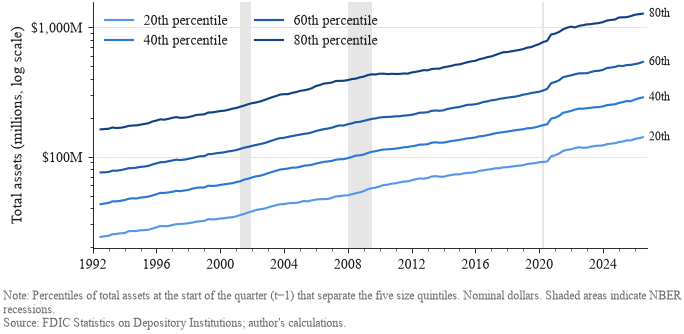

In [7]:
cutoffs = chg.groupby("date")["ASSET_lag"].quantile([0.2, 0.4, 0.6, 0.8]).unstack() / 1e3  # $ millions
asset_share = (chg.groupby(["date", "quintile"])["ASSET_lag"].sum().unstack()
                  .pipe(lambda s: s.div(s.sum(axis=1), axis=0) * 100))
print("Share of industry assets held by each quintile (%), selected quarters:")
display(asset_share.iloc[[0, 60, 120, -1]].round(1).rename(columns=Q_SHORT))

fig, ax = plt.subplots(figsize=(WIDTH, HEIGHT))
shade_recessions(ax)
for (p, color) in zip(cutoffs.columns, QUINTILE_COLORS[1:]):
    ax.plot(cutoffs.index, cutoffs[p], color=color, label=f"{p * 100:.0f}th percentile")
    ax.annotate(f"{p * 100:.0f}th", (cutoffs.index[-1], cutoffs[p].iloc[-1]), xytext=(4, 0),
                textcoords="offset points", va="center", fontsize=8, color=INK)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}M"))
format_time_axis(ax)
ax.set_ylabel("Total assets (millions, log scale)")
ax.legend(loc="upper left", ncols=2)
add_note(fig, "Note: Percentiles of total assets at the start of the quarter (t\u22121) that separate the five size "
              "quintiles. Nominal dollars. Shaded areas indicate NBER recessions." + SOURCE)
save(fig, "quintile_cutoffs")
plt.show()

## Fan charts by size quintile

One panel per quintile, all on a shared axis. Solid line: median bank; dark band: 25th–75th percentiles; light band: 10th–90th percentiles. The panel title names the group, so all panels use one color.

saved output/figures/quintiles/quintile_fan_assets.pdf, .png and _bare.pdf


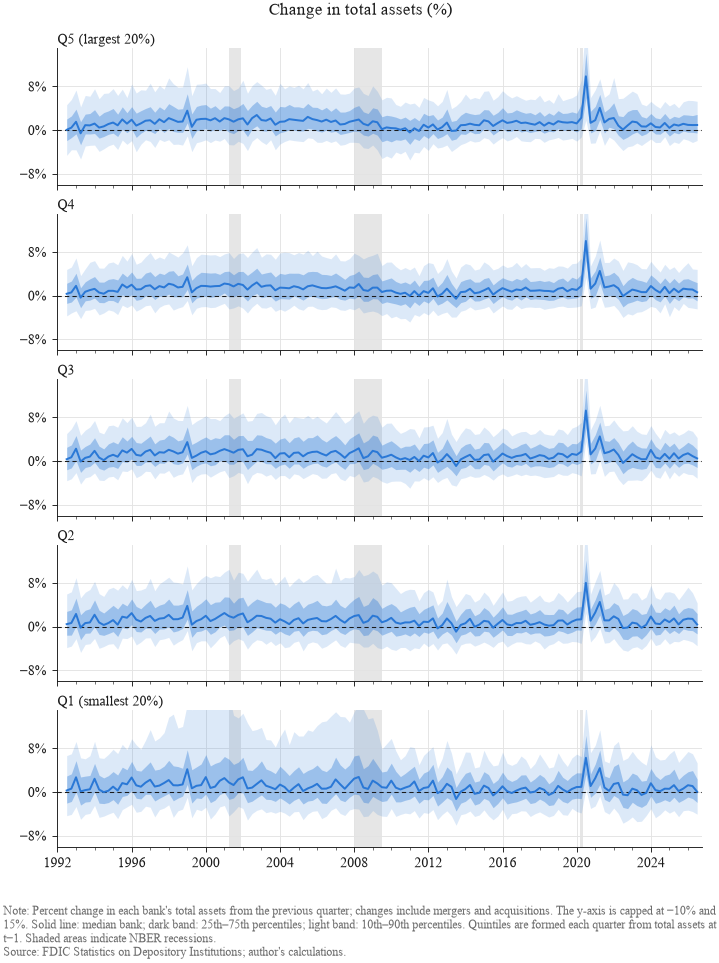

saved output/figures/quintiles/quintile_fan_equity_ratio.pdf, .png and _bare.pdf


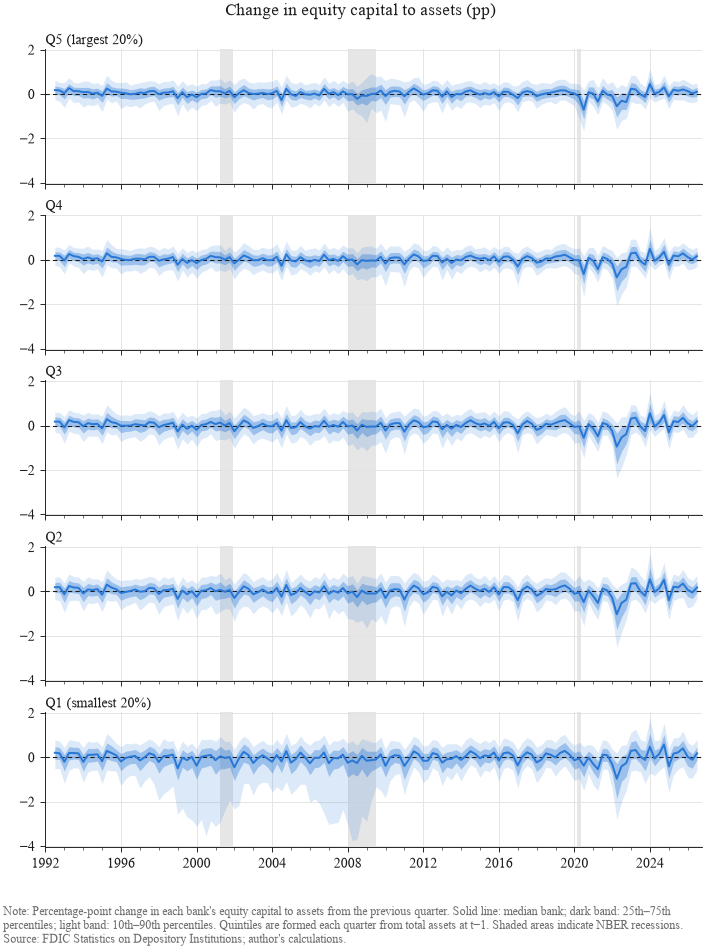

saved output/figures/quintiles/quintile_fan_roa.pdf, .png and _bare.pdf


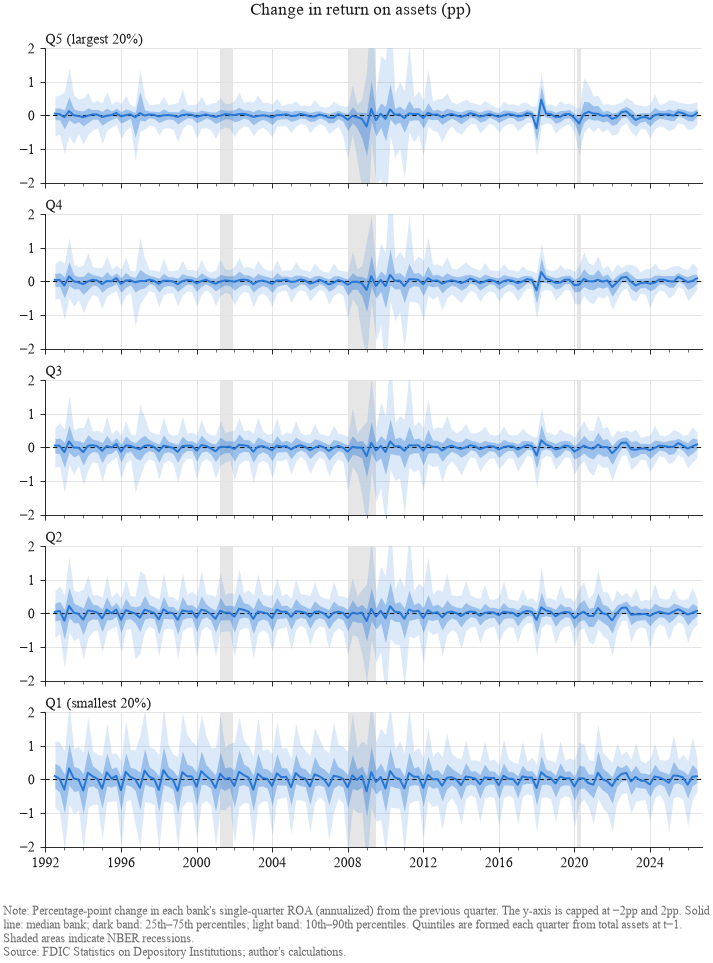

saved output/figures/quintiles/quintile_fan_nim.pdf, .png and _bare.pdf


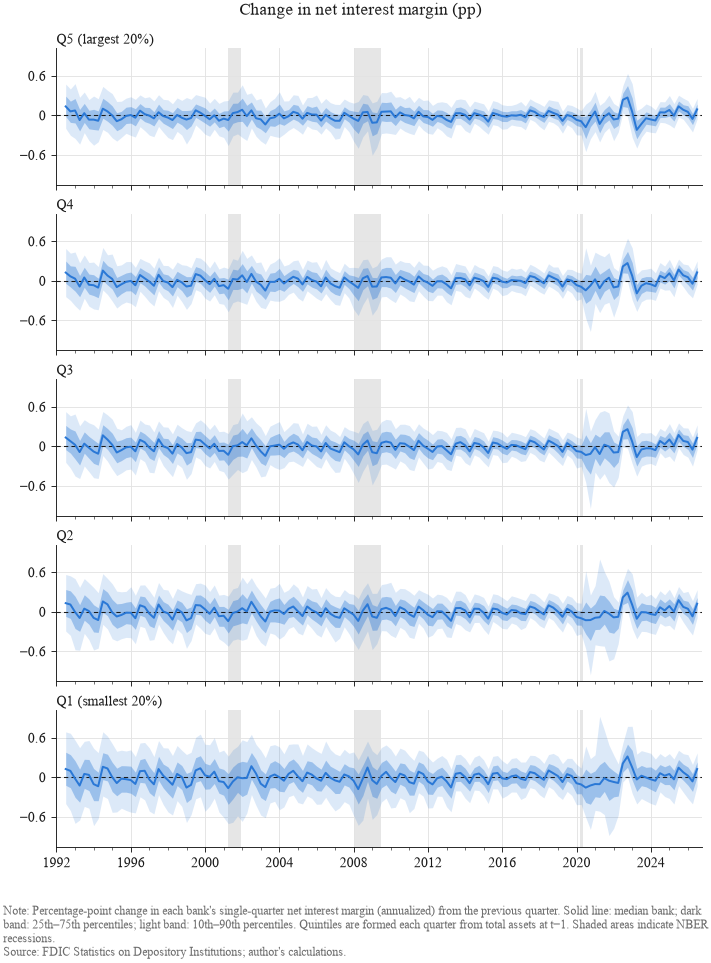

saved output/figures/quintiles/quintile_fan_loans.pdf, .png and _bare.pdf


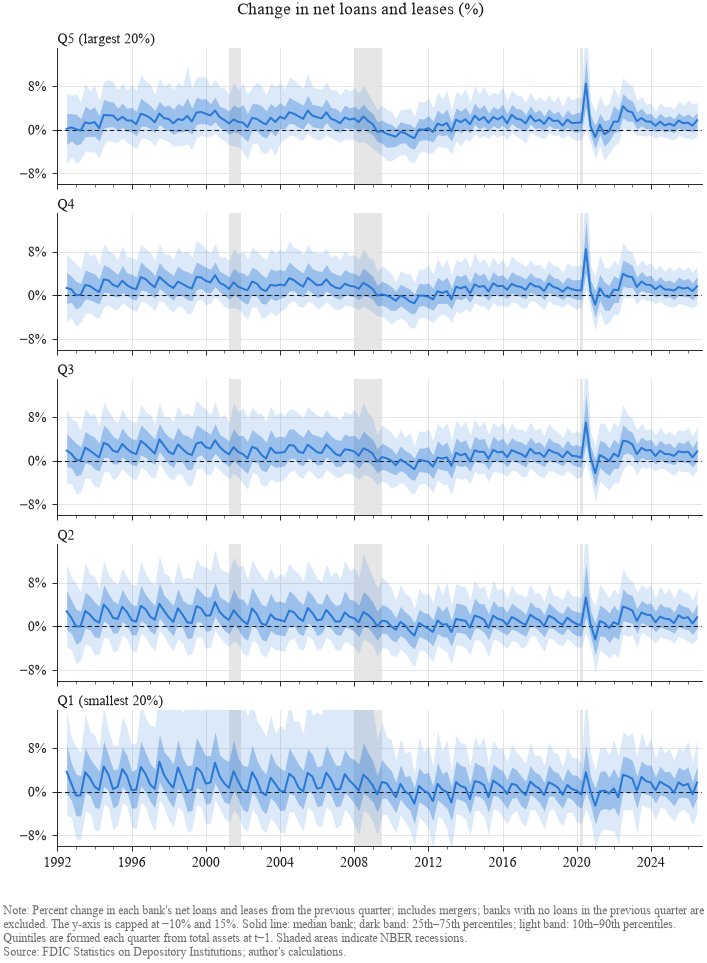

saved output/figures/quintiles/quintile_fan_deposits.pdf, .png and _bare.pdf


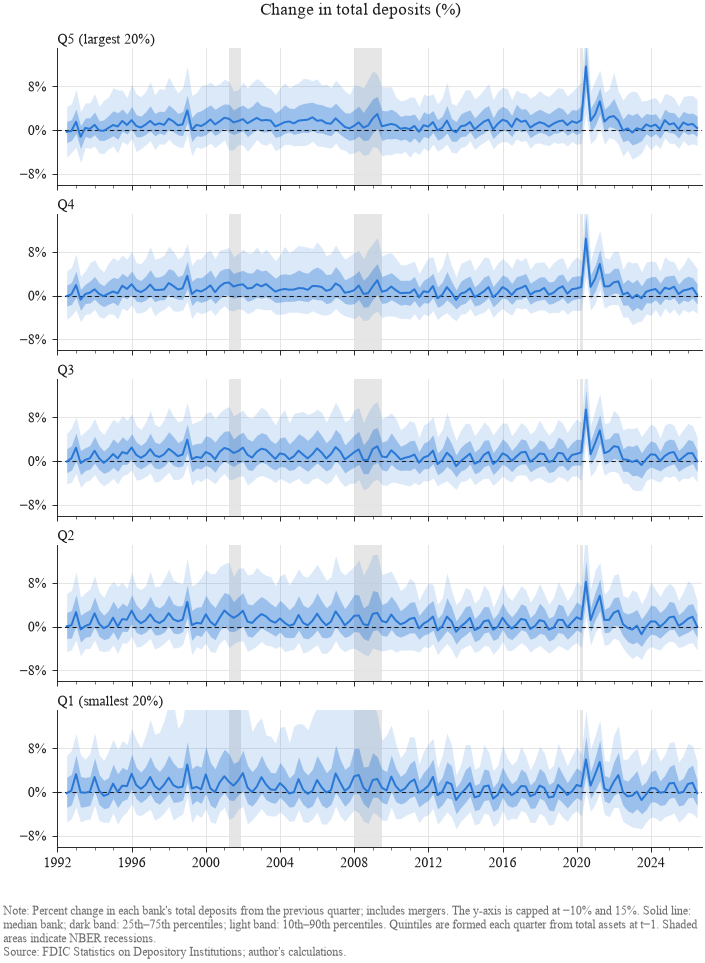

saved output/figures/quintiles/quintile_fan_leverage.pdf, .png and _bare.pdf


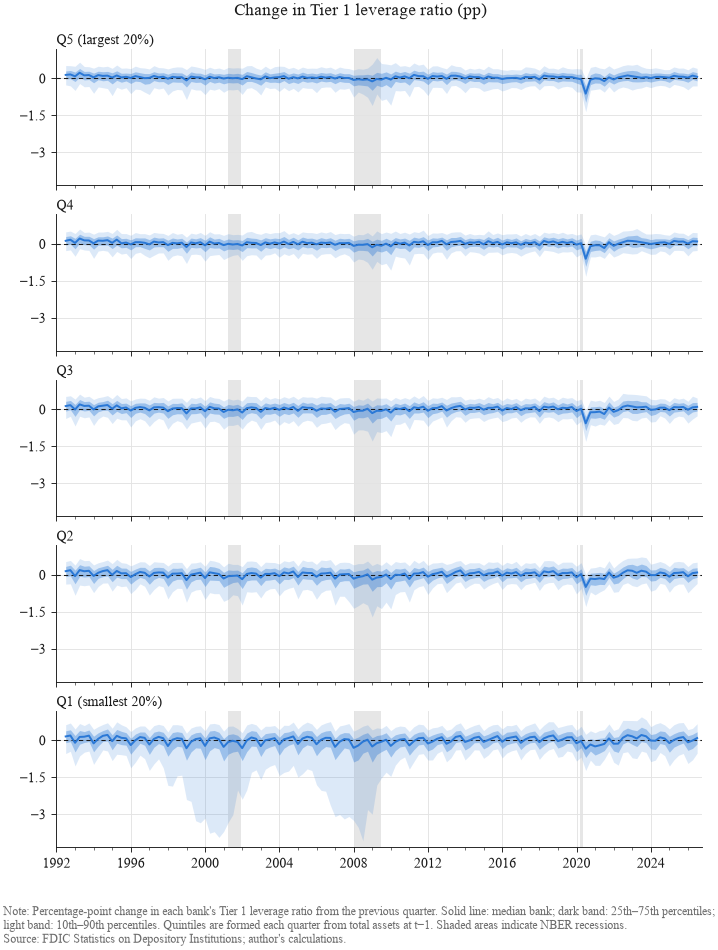

saved output/figures/quintiles/quintile_fan_noncurrent.pdf, .png and _bare.pdf


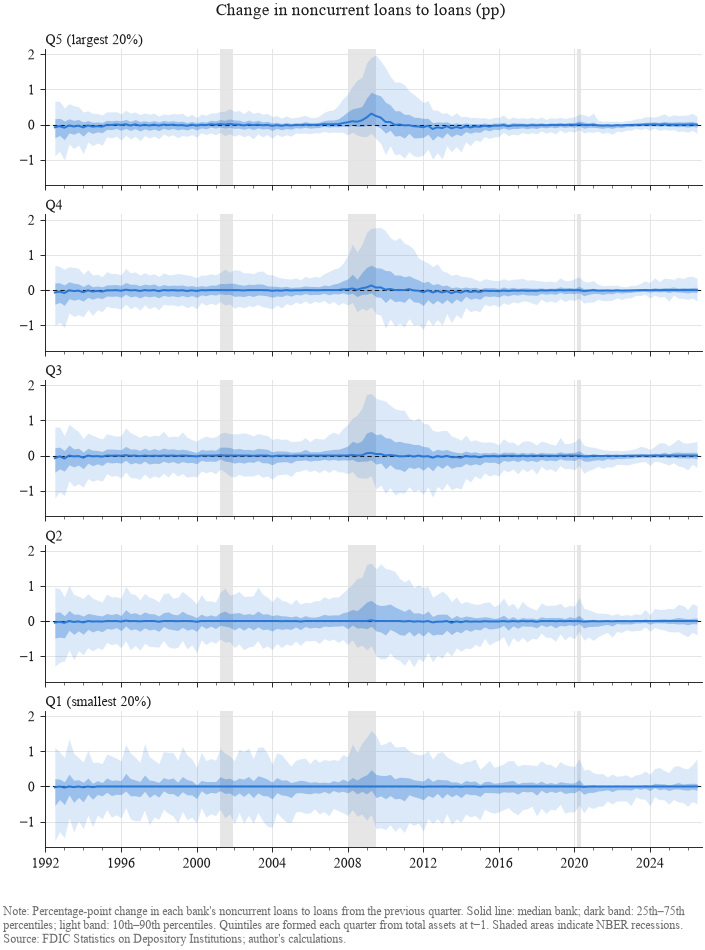

saved output/figures/quintiles/quintile_fan_chargeoffs.pdf, .png and _bare.pdf


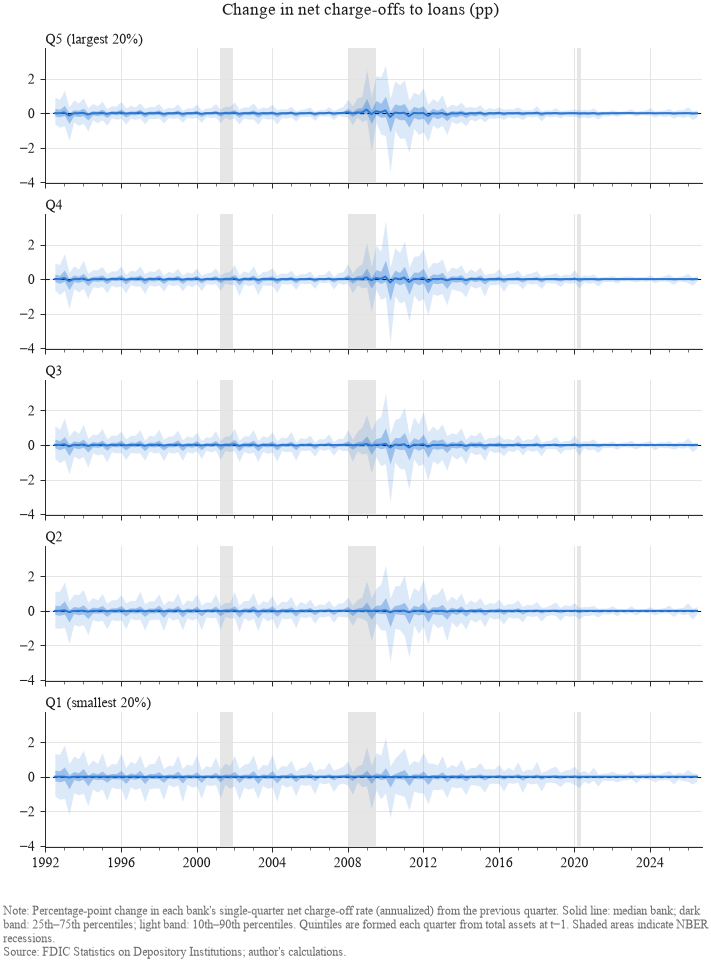

saved output/figures/quintiles/quintile_fan_provisions.pdf, .png and _bare.pdf


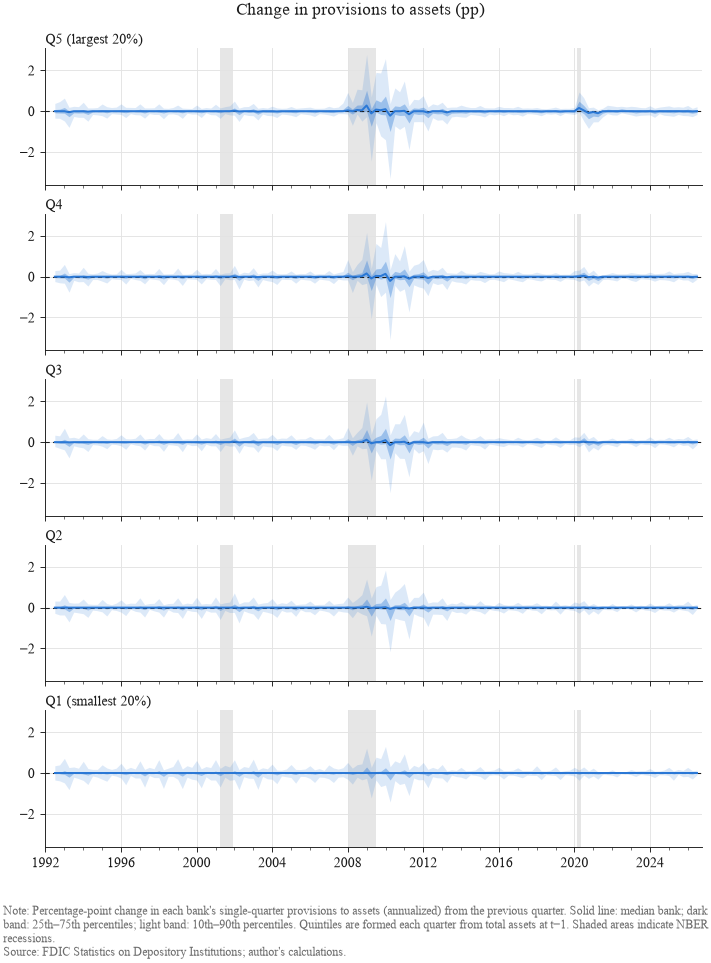

saved output/figures/quintiles/quintile_fan_cost_funds.pdf, .png and _bare.pdf


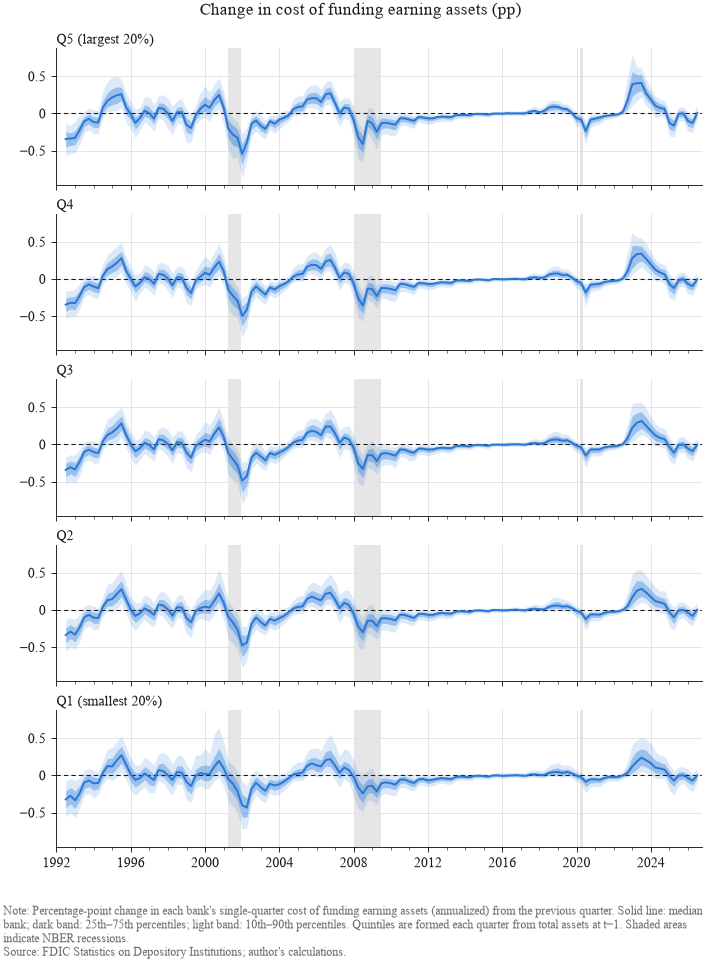

In [8]:
FAN_Q = [0.10, 0.25, 0.50, 0.75, 0.90]
chg_cols = [f"{v}_chg" for v in ALL_VARS]
dist = chg.groupby(["quintile", "date"])[chg_cols].quantile(FAN_Q).unstack()  # columns: (var_chg, quantile)
BAND_NOTE = ("Solid line: median bank; dark band: 25th\u201375th percentiles; light band: 10th\u201390th percentiles. "
             "Quintiles are formed each quarter from total assets at t\u22121. Shaded areas indicate NBER recessions.")


def fan_figure(var):
    fig, axes = plt.subplots(5, 1, figsize=(WIDTH, 8.2), sharex=True, sharey=True)
    for ax, qi in zip(axes, reversed(QUINTILES)):  # largest on top
        d = dist.loc[qi, f"{var}_chg"]
        shade_recessions(ax)
        ax.fill_between(d.index, d[0.10], d[0.90], color=SERIES[0], alpha=0.16, lw=0, zorder=1)
        ax.fill_between(d.index, d[0.25], d[0.75], color=SERIES[0], alpha=0.36, lw=0, zorder=2)
        ax.axhline(0, color=INK, lw=0.7, ls=(0, (4, 3)), zorder=3)
        ax.plot(d.index, d[0.50], color=SERIES[0], lw=1.3, zorder=4)
        ax.set_title(Q_LABELS[qi], loc="left", fontsize=9, pad=3)
        format_time_axis(ax)
        ax.grid(True, axis="both", color=GRID, lw=0.6)
        ax.set_axisbelow(True)
    axes[0].yaxis.set_major_formatter(fmt_for(var))
    axes[0].yaxis.set_major_locator(MaxNLocator(4))
    if var in Y_LIMITS:
        axes[0].set_ylim(*Y_LIMITS[var])
    fig.suptitle(ALL_VARS[var], fontsize=11, gid="title")
    fig.tight_layout(h_pad=0.6)
    lo, hi = (f"{v:g}{unit_for(var).strip()}".replace("-", "−") for v in Y_LIMITS.get(var, (0, 0)))
    cap = f" The y-axis is capped at {lo} and {hi}." if var in Y_LIMITS else ""
    add_note(fig, "Note: " + VAR_NOTES[var] + cap + " " + BAND_NOTE + SOURCE)
    return fig


for var in ALL_VARS:
    fig = fan_figure(var)
    save(fig, f"quintile_fan_{var}")
    plt.show()

## Kernel density estimates

Gaussian kernel, Silverman's rule-of-thumb bandwidth ($h = 0.9\,\min(\hat\sigma, \mathrm{IQR}/1.34)\, n^{-1/5}$), computed separately for each sample. With up to a million observations per sample, the density is computed on a fine grid (linear binning followed by convolution with the kernel), which matches the exact estimate to plotting precision and uses every observation.

Densities are drawn over the pooled 1st–99th percentile range of each variable. Observations outside that window still count in the denominator, so each curve integrates to the share of its sample inside the window, not to one. Merger-driven asset jumps and 2008–09 ROA losses lie mostly outside the window.

In [9]:
def kde(x, lo, hi, n_grid=2048):
    """Binned Gaussian KDE of x on [lo, hi], normalized by the full sample size."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    sd = x.std()
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    spread = min(sd, iqr / 1.34) if iqr > 0 else sd
    h = 0.9 * spread * n ** -0.2
    dx = (hi - lo) / (n_grid - 1)
    pad = int(np.ceil(4 * h / dx))
    centers = lo + dx * np.arange(-pad, n_grid + pad)
    counts, _ = np.histogram(x, bins=np.append(centers - dx / 2, centers[-1] + dx / 2))
    offsets = dx * np.arange(-pad, pad + 1)
    kernel = np.exp(-0.5 * (offsets / h) ** 2)
    kernel /= kernel.sum() * dx
    dens = np.convolve(counts, kernel, mode="same") / n
    return centers[pad:pad + n_grid], dens[pad:pad + n_grid]


def style_density_axis(ax, var):
    ax.set_xlim(*KDE_RANGE[var])
    ax.set_ylim(0, None)
    ax.xaxis.set_major_formatter(fmt_for(var))
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.axvline(0, color=INK, lw=0.6, ls=(0, (4, 3)), zorder=1)
    ax.grid(True, axis="x", color=GRID, lw=0.6)
    ax.set_yticklabels([])
    ax.tick_params(axis="y", length=0)

### Pooled distribution by size quintile

All quarters pooled. Shows whether size groups differ in location, spread and tail shape on average over the sample.

saved output/figures/quintiles/quintile_kde_assets.pdf, .png and _bare.pdf


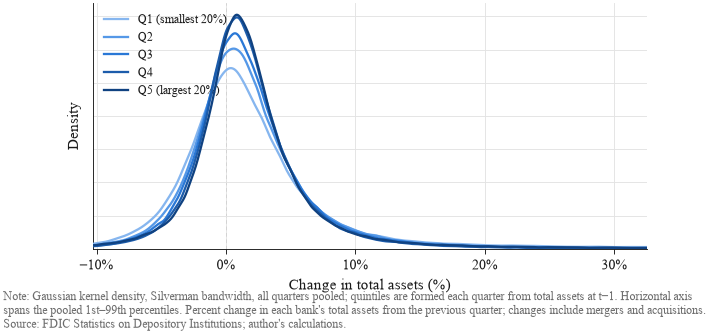

saved output/figures/quintiles/quintile_kde_equity_ratio.pdf, .png and _bare.pdf


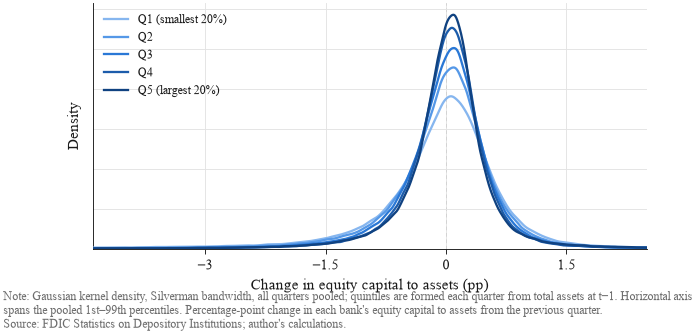

saved output/figures/quintiles/quintile_kde_roa.pdf, .png and _bare.pdf


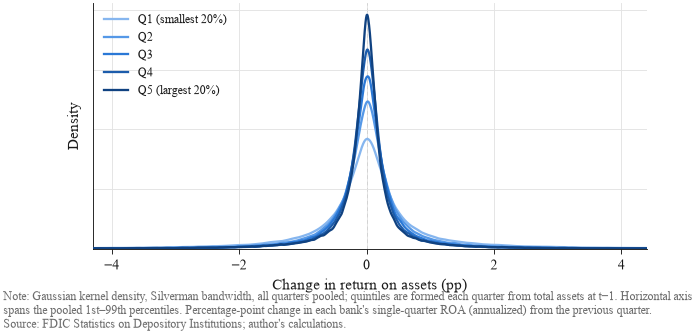

saved output/figures/quintiles/quintile_kde_nim.pdf, .png and _bare.pdf


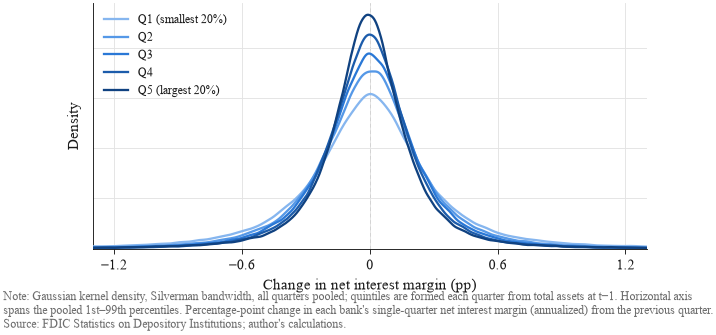

saved output/figures/quintiles/quintile_kde_loans.pdf, .png and _bare.pdf


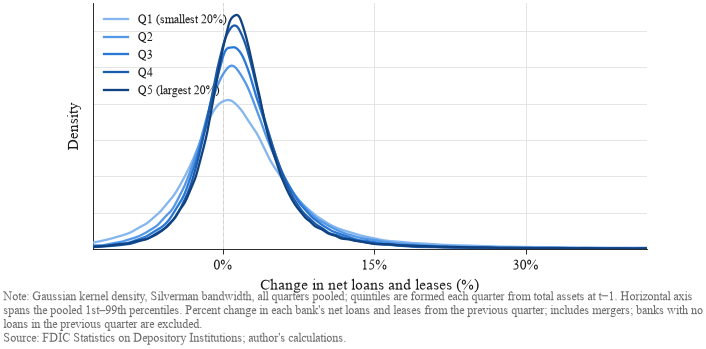

saved output/figures/quintiles/quintile_kde_deposits.pdf, .png and _bare.pdf


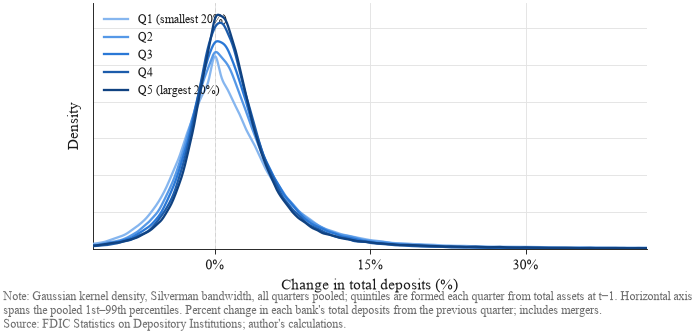

saved output/figures/quintiles/quintile_kde_leverage.pdf, .png and _bare.pdf


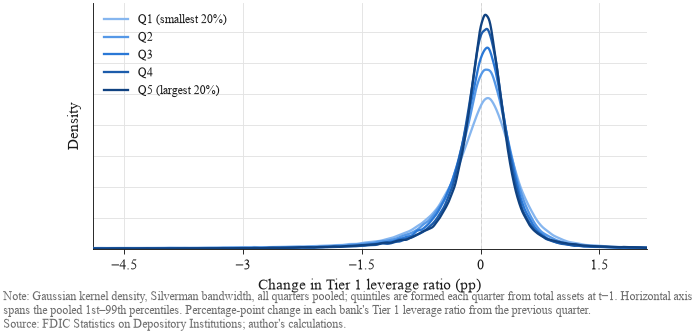

saved output/figures/quintiles/quintile_kde_noncurrent.pdf, .png and _bare.pdf


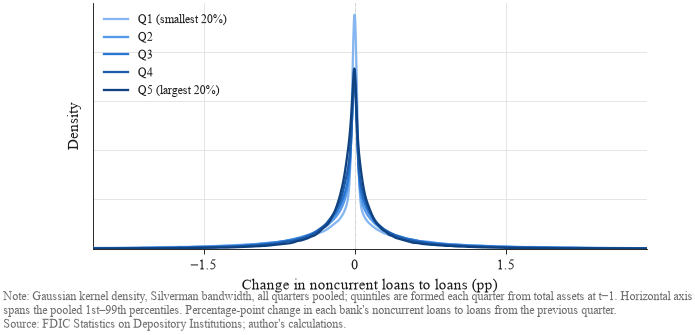

saved output/figures/quintiles/quintile_kde_chargeoffs.pdf, .png and _bare.pdf


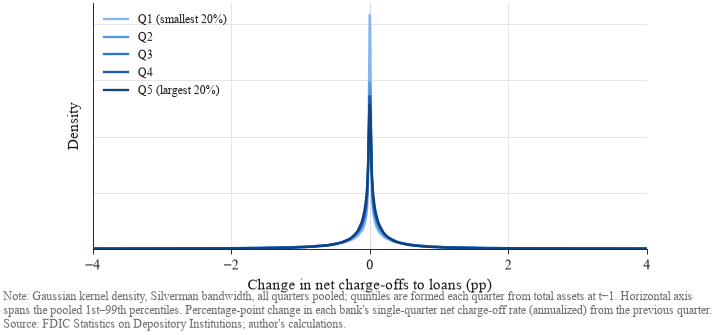

saved output/figures/quintiles/quintile_kde_provisions.pdf, .png and _bare.pdf


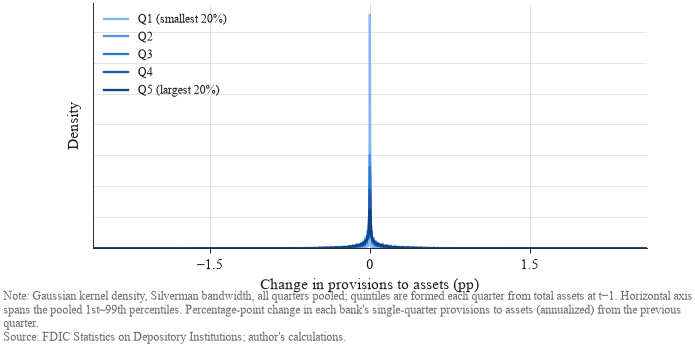

saved output/figures/quintiles/quintile_kde_cost_funds.pdf, .png and _bare.pdf


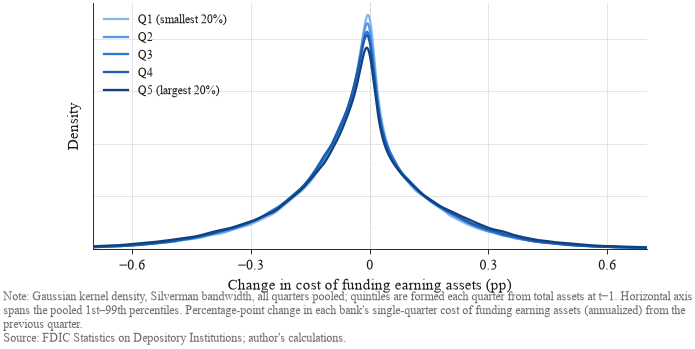

In [10]:
def kde_by_quintile(var):
    lo, hi = KDE_RANGE[var]
    fig, ax = plt.subplots(figsize=(WIDTH, HEIGHT))
    for qi, color in zip(QUINTILES, QUINTILE_COLORS):
        xs, ys = kde(chg.loc[chg["quintile"] == qi, f"{var}_chg"], lo, hi)
        ax.plot(xs, ys, color=color, lw=1.5, label=Q_LABELS[qi], zorder=2 + qi)
    style_density_axis(ax, var)
    ax.set_xlabel(ALL_VARS[var])
    ax.set_ylabel("Density")
    ax.legend(loc="upper left", fontsize=8)
    add_note(fig, "Note: Gaussian kernel density, Silverman bandwidth, all quarters pooled; quintiles are formed each "
                  "quarter from total assets at t\u22121. Horizontal axis spans the pooled 1st\u201399th percentiles. "
                  + VAR_NOTES[var] + SOURCE)
    return fig


for var in ALL_VARS:
    fig = kde_by_quintile(var)
    save(fig, f"quintile_kde_{var}")
    plt.show()

### Expansion versus recession, within each size quintile

The core comparison for the research question. Each panel holds one size group fixed and compares the distribution of changes in expansion quarters (blue) with recession quarters (orange). The sixth panel pools all banks. Recession quarters are dominated by 2008–09 (6 of 11).

saved output/figures/quintiles/quintile_kde_cycle_assets.pdf, .png and _bare.pdf


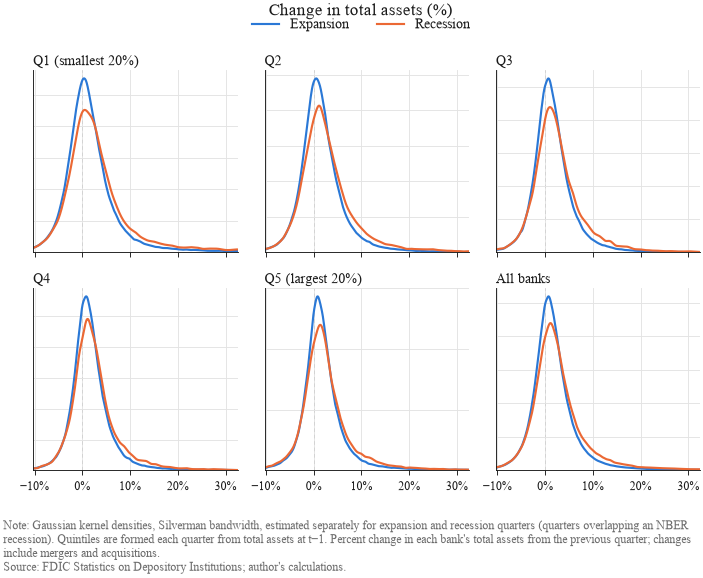

saved output/figures/quintiles/quintile_kde_cycle_equity_ratio.pdf, .png and _bare.pdf


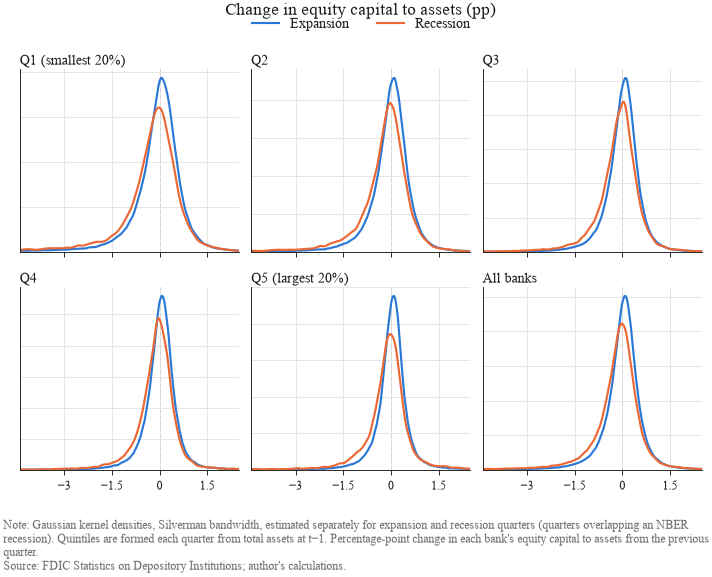

saved output/figures/quintiles/quintile_kde_cycle_roa.pdf, .png and _bare.pdf


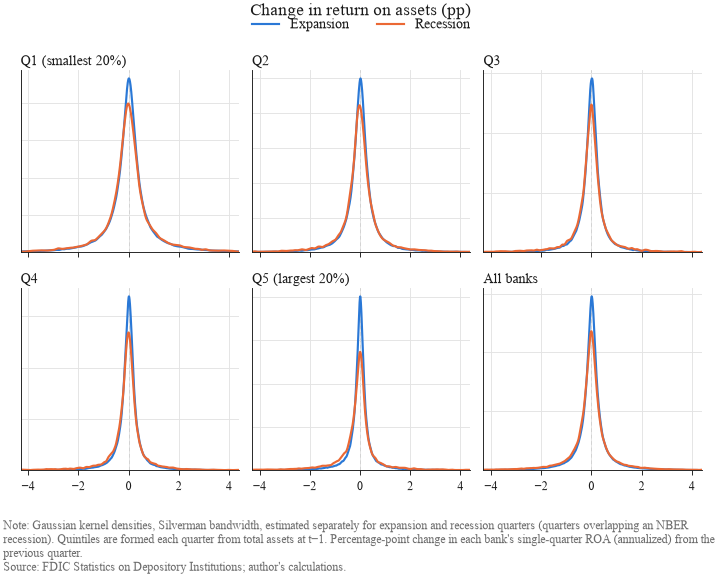

saved output/figures/quintiles/quintile_kde_cycle_nim.pdf, .png and _bare.pdf


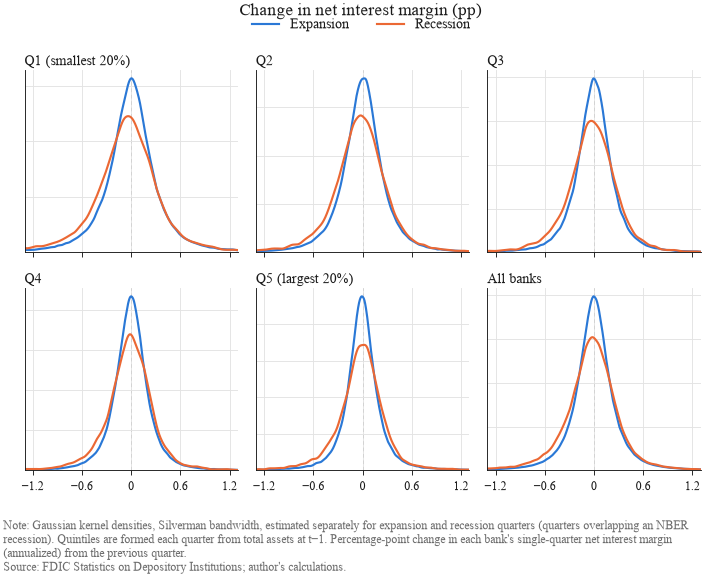

saved output/figures/quintiles/quintile_kde_cycle_loans.pdf, .png and _bare.pdf


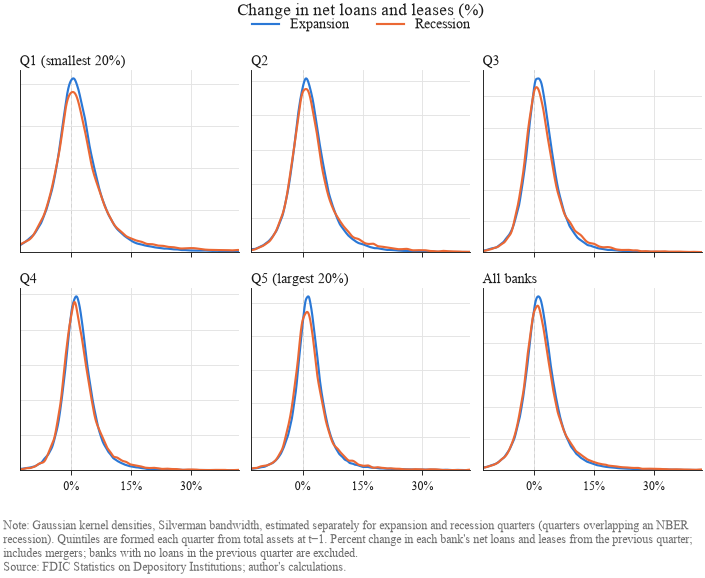

saved output/figures/quintiles/quintile_kde_cycle_deposits.pdf, .png and _bare.pdf


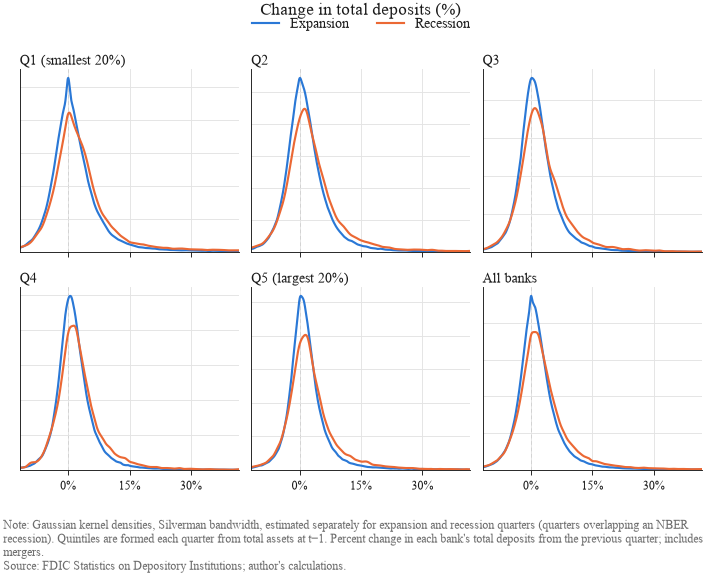

saved output/figures/quintiles/quintile_kde_cycle_leverage.pdf, .png and _bare.pdf


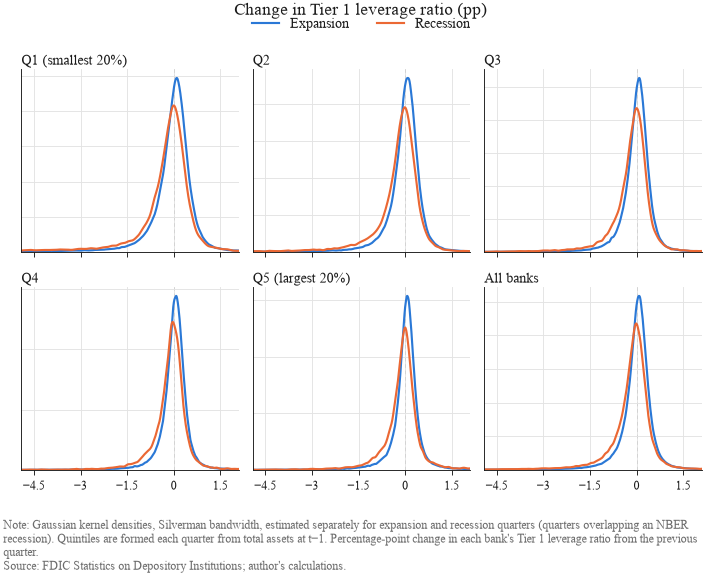

saved output/figures/quintiles/quintile_kde_cycle_noncurrent.pdf, .png and _bare.pdf


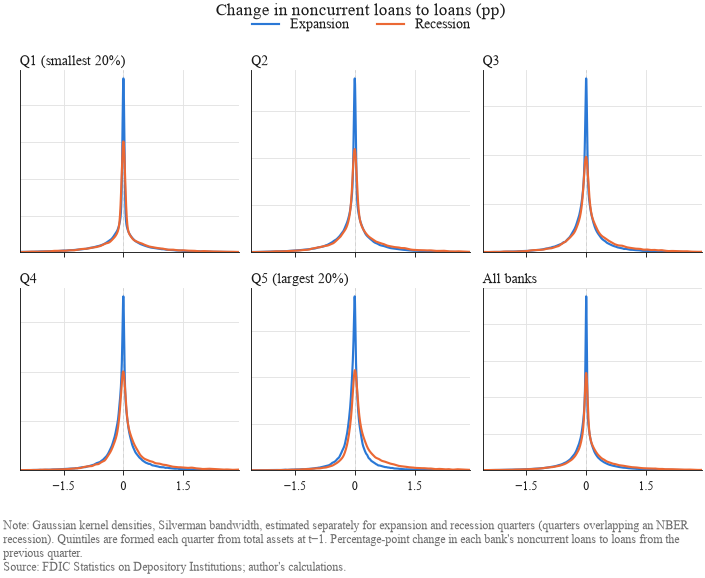

saved output/figures/quintiles/quintile_kde_cycle_chargeoffs.pdf, .png and _bare.pdf


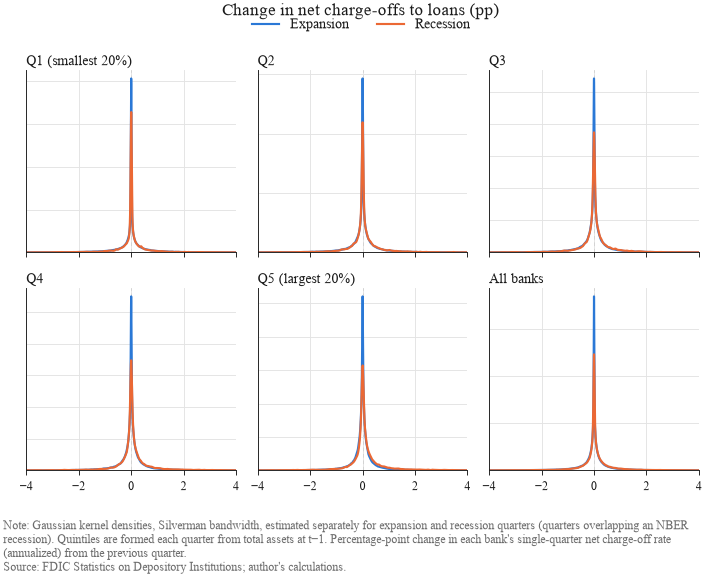

saved output/figures/quintiles/quintile_kde_cycle_provisions.pdf, .png and _bare.pdf


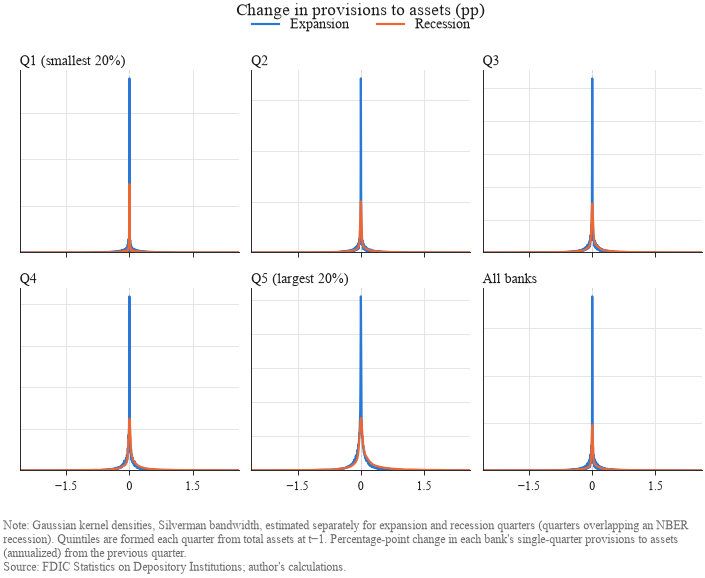

saved output/figures/quintiles/quintile_kde_cycle_cost_funds.pdf, .png and _bare.pdf


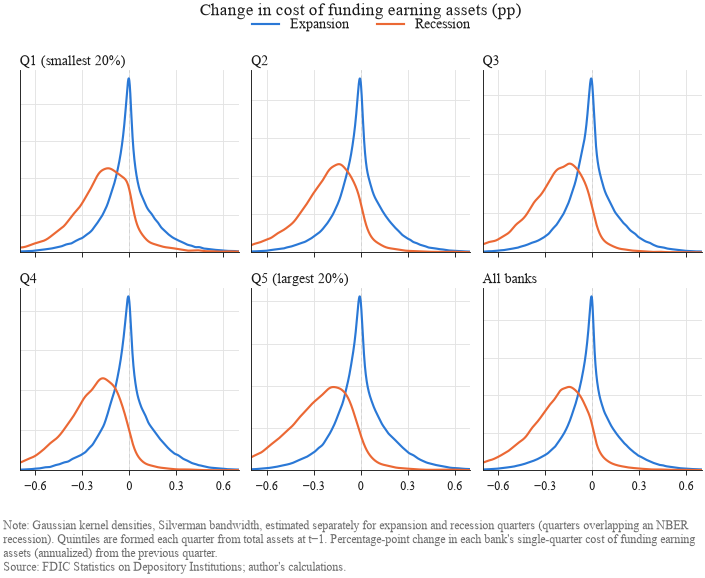

In [11]:
def kde_cycle(var):
    lo, hi = KDE_RANGE[var]
    fig, axes = plt.subplots(2, 3, figsize=(WIDTH, 4.6), sharex=True)
    groups = [(Q_LABELS[qi], chg["quintile"] == qi) for qi in QUINTILES] + [("All banks", slice(None))]
    for ax, (title, rows) in zip(axes.flat, groups):
        sub = chg.loc[rows]
        for rec, color, label in [(False, SERIES[0], "Expansion"), (True, SERIES[1], "Recession")]:
            xs, ys = kde(sub.loc[sub["recession"] == rec, f"{var}_chg"], lo, hi)
            ax.plot(xs, ys, color=color, lw=1.4, label=label)
        style_density_axis(ax, var)
        ax.set_title(title, fontsize=9, loc="left", pad=3)
        ax.tick_params(axis="x", labelsize=8)
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.tight_layout(h_pad=1.0, w_pad=0.8, rect=(0, 0, 1, 0.93))
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.92), ncols=2)
    fig.suptitle(ALL_VARS[var], fontsize=11, y=1.0, gid="title")
    add_note(fig, "Note: Gaussian kernel densities, Silverman bandwidth, estimated separately for expansion and "
                  "recession quarters (quarters overlapping an NBER recession). Quintiles are formed each quarter from "
                  "total assets at t\u22121. " + VAR_NOTES[var] + SOURCE)
    return fig


for var in ALL_VARS:
    fig = kde_cycle(var)
    save(fig, f"quintile_kde_cycle_{var}")
    plt.show()

### Ridgeline: the distribution year by year

All banks, one kernel density per calendar year (all four quarters pooled), stacked top to bottom. Years that overlap an NBER recession are drawn in orange. This shows the whole distribution moving through the cycle, not just a few quantiles. Each curve is scaled to the same peak height so shape, not sample size, is compared; the sample shrinks from about 13,000 banks per quarter in 1993 to about 4,200 in 2026.

saved output/figures/quintiles/ridgeline_assets.pdf, .png and _bare.pdf


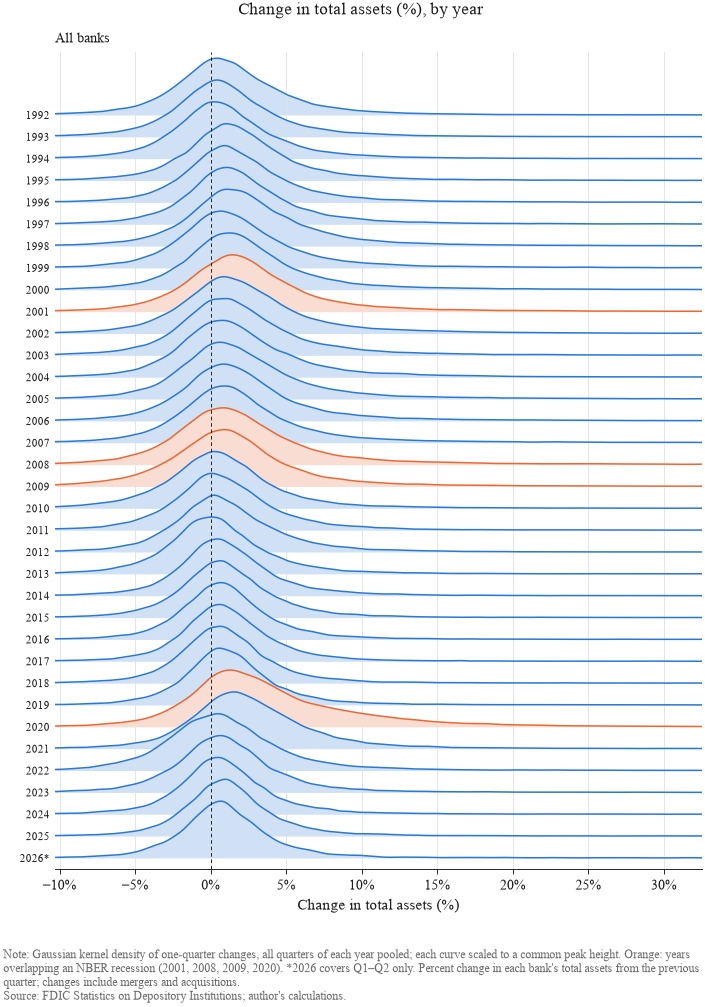

saved output/figures/quintiles/ridgeline_equity_ratio.pdf, .png and _bare.pdf


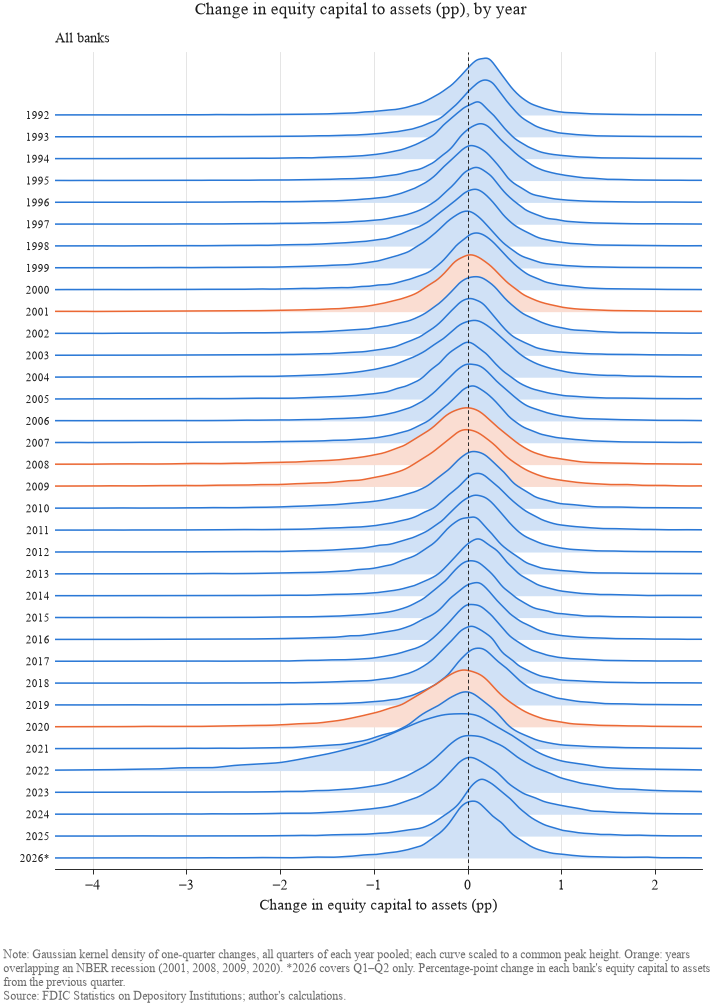

saved output/figures/quintiles/ridgeline_roa.pdf, .png and _bare.pdf


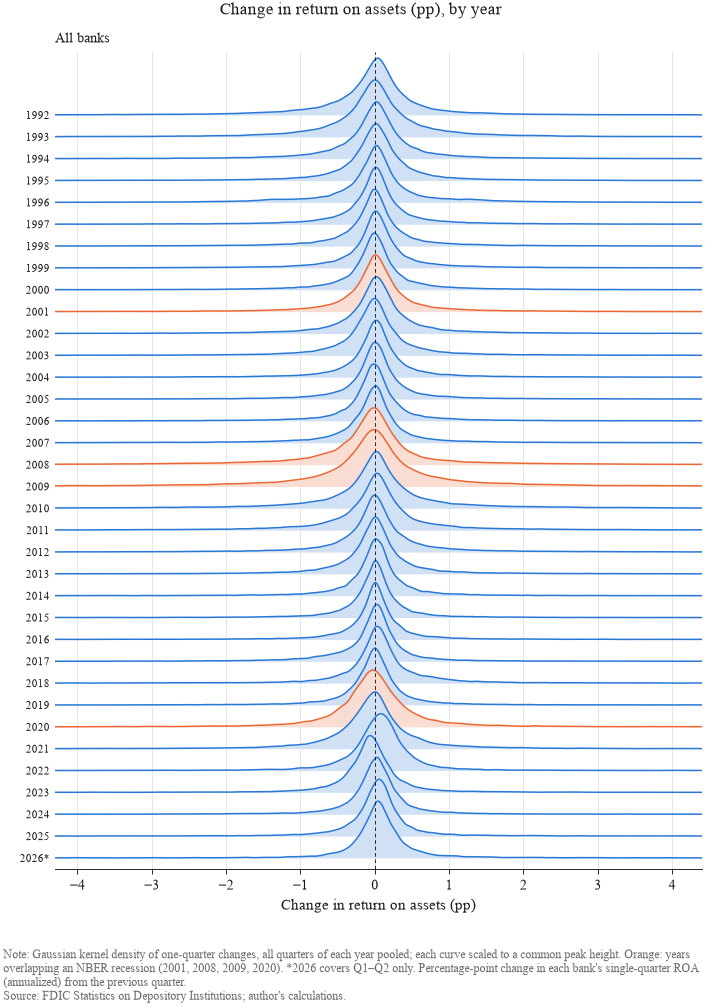

saved output/figures/quintiles/ridgeline_nim.pdf, .png and _bare.pdf


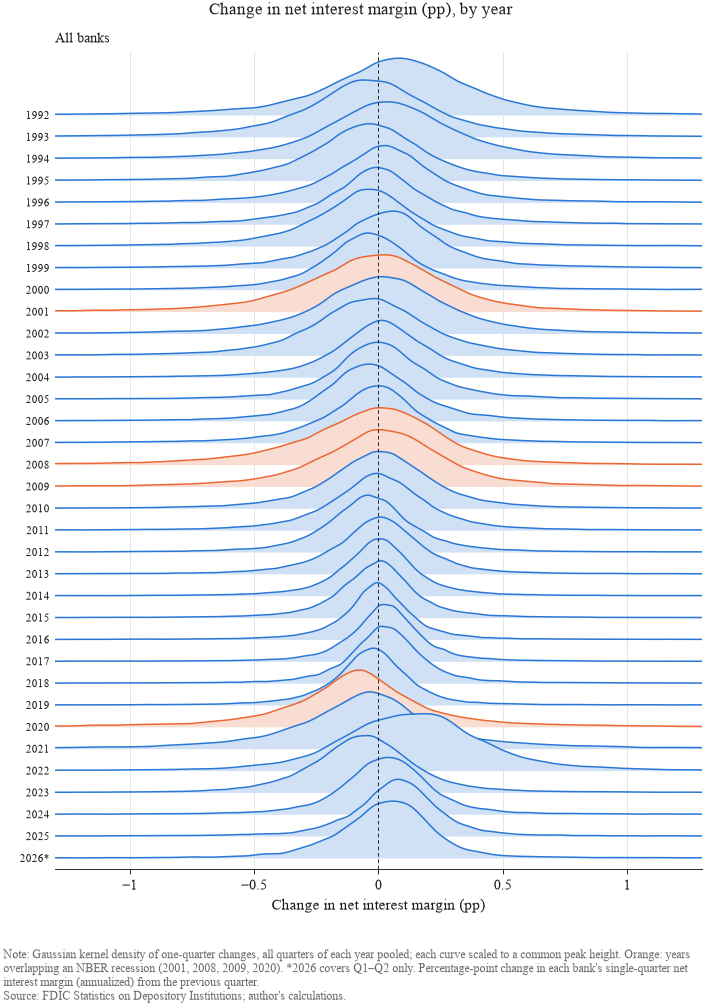

In [12]:
REC_YEARS = {d.year for d, r in rec_by_date.items() if r}


def ridgeline(var, rows=slice(None), group_label="All banks"):
    lo, hi = KDE_RANGE[var]
    sub = chg.loc[rows]
    years = sorted(sub["date"].dt.year.unique())
    step, height = 1.0, 2.6  # vertical spacing between years, and peak height in those units
    fig, ax = plt.subplots(figsize=(WIDTH, 8.6))
    for i, year in enumerate(years):
        xs, ys = kde(sub.loc[sub["date"].dt.year == year, f"{var}_chg"], lo, hi, n_grid=1024)
        base = -i * step
        top = base + ys / ys.max() * height
        color = SERIES[1] if year in REC_YEARS else SERIES[0]
        ax.fill_between(xs, base, top, color="white", lw=0, zorder=2 * i + 1)
        ax.fill_between(xs, base, top, color=color, alpha=0.22, lw=0, zorder=2 * i + 1)
        ax.plot(xs, top, color=color, lw=1.0, zorder=2 * i + 2)
    ax.set_yticks([-i * step for i in range(len(years))])
    ax.set_yticklabels([str(y) + ("*" if y == years[-1] and y == 2026 else "") for y in years], fontsize=7.5)
    ax.tick_params(axis="y", length=0)
    ax.set_ylim(-(len(years) - 1) * step - 0.5, height + 0.3)
    ax.set_xlim(lo, hi)
    ax.axvline(0, color=INK, lw=0.6, ls=(0, (4, 3)), zorder=200)
    ax.xaxis.set_major_formatter(fmt_for(var))
    ax.grid(True, axis="x", color=GRID, lw=0.6)
    ax.grid(False, axis="y")
    ax.spines["left"].set_visible(False)
    ax.set_xlabel(ALL_VARS[var])
    ax.set_title(group_label, loc="left", fontsize=9)
    fig.suptitle(ALL_VARS[var] + ", by year", fontsize=11, gid="title")
    fig.tight_layout()
    add_note(fig, "Note: Gaussian kernel density of one-quarter changes, all quarters of each year pooled; each curve "
                  "scaled to a common peak height. Orange: years overlapping an NBER recession (2001, 2008, 2009, "
                  "2020). *2026 covers Q1\u2013Q2 only. " + VAR_NOTES[var] + SOURCE)
    return fig


for var in CORE_VARS:
    fig = ridgeline(var)
    save(fig, f"ridgeline_{var}")
    plt.show()

## Empirical histograms (no smoothing)

The kernel densities above depend on a bandwidth choice. As a check, the same two displays are redrawn as plain histograms: equal-width bins over the same pooled 1st–99th percentile window, with no kernel and no smoothing. Heights use the KDE's normalization (bin count divided by the full sample size and the bin width), so each histogram is on the same vertical scale as its kernel counterpart and sums to the share of the sample inside the window.

Bin counts: 120 bins for the pooled quintile histograms (hundreds of thousands of observations per quintile) and 80 bins for the yearly ridgelines (roughly 16,000–50,000 observations per year).

In [13]:
HIST_BINS_POOLED, HIST_BINS_RIDGE = 120, 80


def hist_density(x, lo, hi, bins):
    """Equal-width histogram of x on [lo, hi], normalized by the full sample size like kde()."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    edges = np.linspace(lo, hi, bins + 1)
    counts, _ = np.histogram(x, bins=edges)
    return edges, counts / (len(x) * np.diff(edges))


### Pooled histogram by size quintile

Unsmoothed counterpart of the pooled KDE by quintile. Each quintile is drawn as a step outline on common bins.

saved output/figures/quintiles/quintile_hist_assets.pdf, .png and _bare.pdf


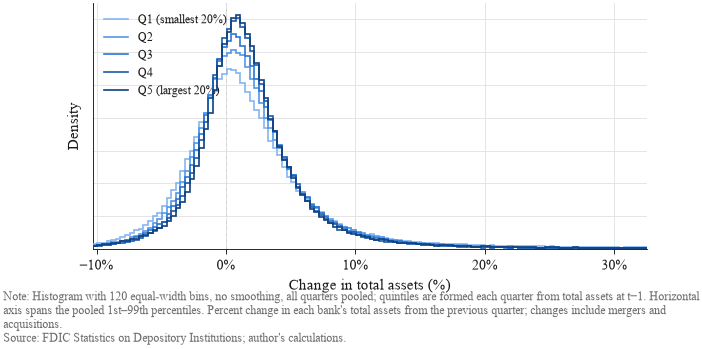

saved output/figures/quintiles/quintile_hist_equity_ratio.pdf, .png and _bare.pdf


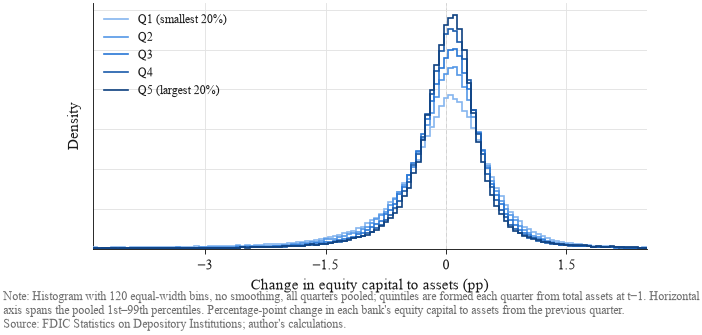

saved output/figures/quintiles/quintile_hist_roa.pdf, .png and _bare.pdf


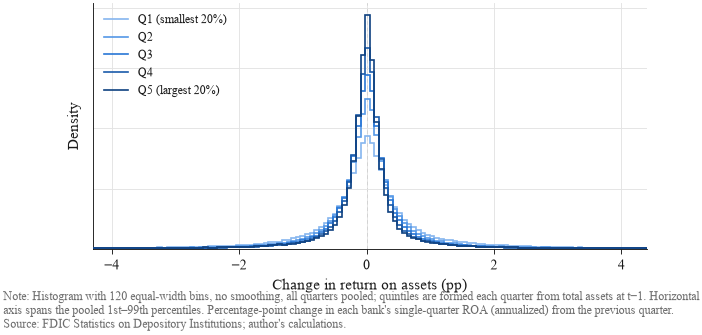

saved output/figures/quintiles/quintile_hist_nim.pdf, .png and _bare.pdf


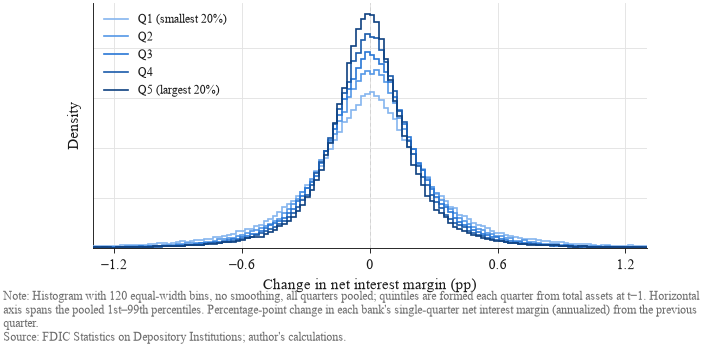

saved output/figures/quintiles/quintile_hist_loans.pdf, .png and _bare.pdf


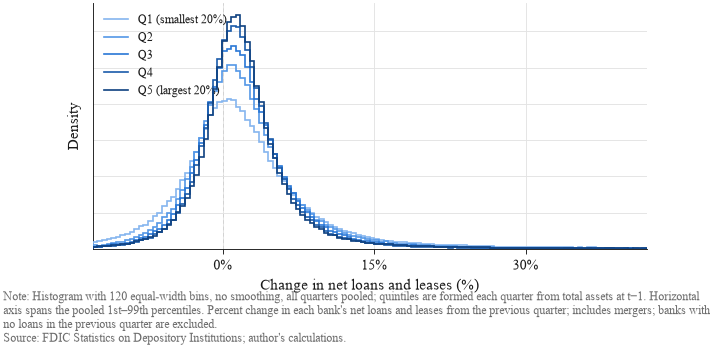

saved output/figures/quintiles/quintile_hist_deposits.pdf, .png and _bare.pdf


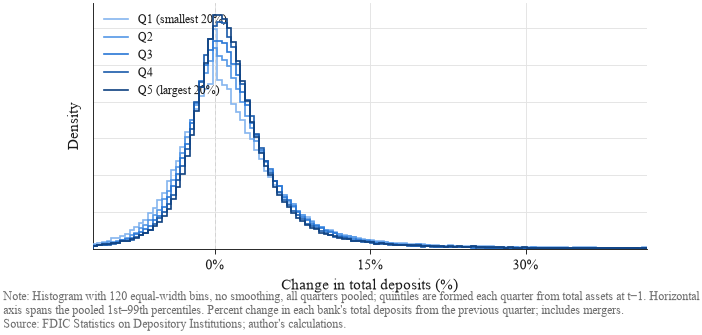

saved output/figures/quintiles/quintile_hist_leverage.pdf, .png and _bare.pdf


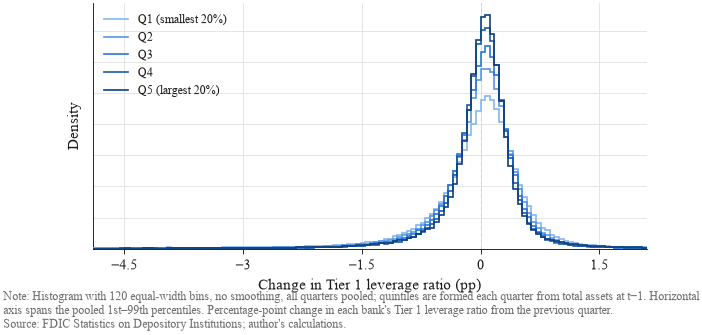

saved output/figures/quintiles/quintile_hist_noncurrent.pdf, .png and _bare.pdf


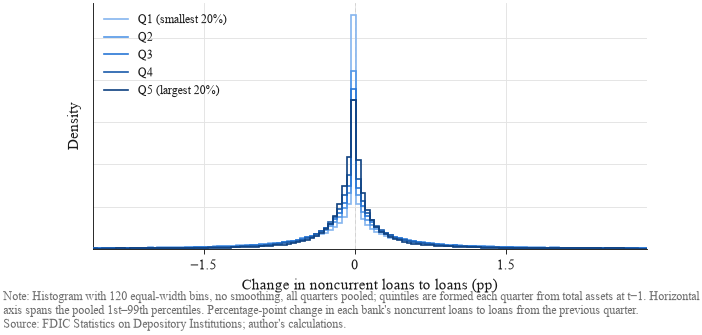

saved output/figures/quintiles/quintile_hist_chargeoffs.pdf, .png and _bare.pdf


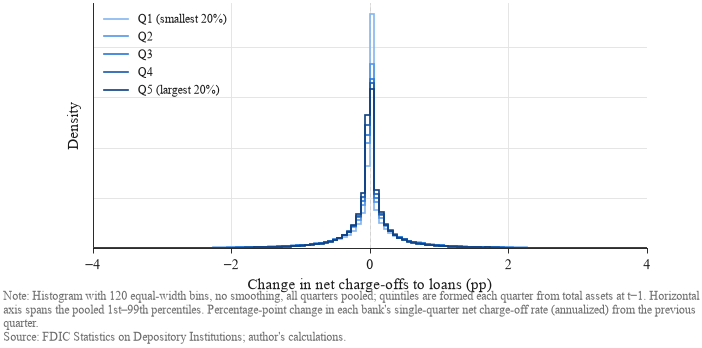

saved output/figures/quintiles/quintile_hist_provisions.pdf, .png and _bare.pdf


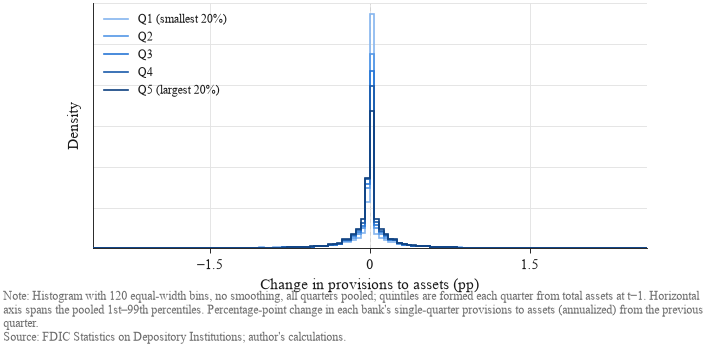

saved output/figures/quintiles/quintile_hist_cost_funds.pdf, .png and _bare.pdf


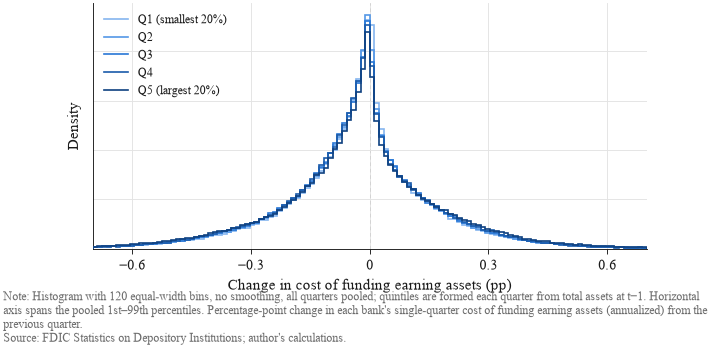

In [14]:
def hist_by_quintile(var):
    lo, hi = KDE_RANGE[var]
    fig, ax = plt.subplots(figsize=(WIDTH, HEIGHT))
    for qi, color in zip(QUINTILES, QUINTILE_COLORS):
        edges, dens = hist_density(chg.loc[chg["quintile"] == qi, f"{var}_chg"], lo, hi, HIST_BINS_POOLED)
        ax.stairs(dens, edges, color=color, lw=1.1, label=Q_LABELS[qi], zorder=2 + qi)
    style_density_axis(ax, var)
    ax.set_xlabel(ALL_VARS[var])
    ax.set_ylabel("Density")
    ax.legend(loc="upper left", fontsize=8)
    add_note(fig, f"Note: Histogram with {HIST_BINS_POOLED} equal-width bins, no smoothing, all quarters pooled; "
                  "quintiles are formed each quarter from total assets at t−1. Horizontal axis spans the pooled "
                  "1st–99th percentiles. " + VAR_NOTES[var] + SOURCE)
    return fig


for var in ALL_VARS:
    fig = hist_by_quintile(var)
    save(fig, f"quintile_hist_{var}")
    plt.show()


### Ridgeline histograms: the distribution year by year

Unsmoothed counterpart of the ridgeline: one histogram per calendar year, all banks, all quarters of the year pooled, each scaled to a common peak height. Orange marks years overlapping an NBER recession.

saved output/figures/quintiles/ridgeline_hist_assets.pdf, .png and _bare.pdf


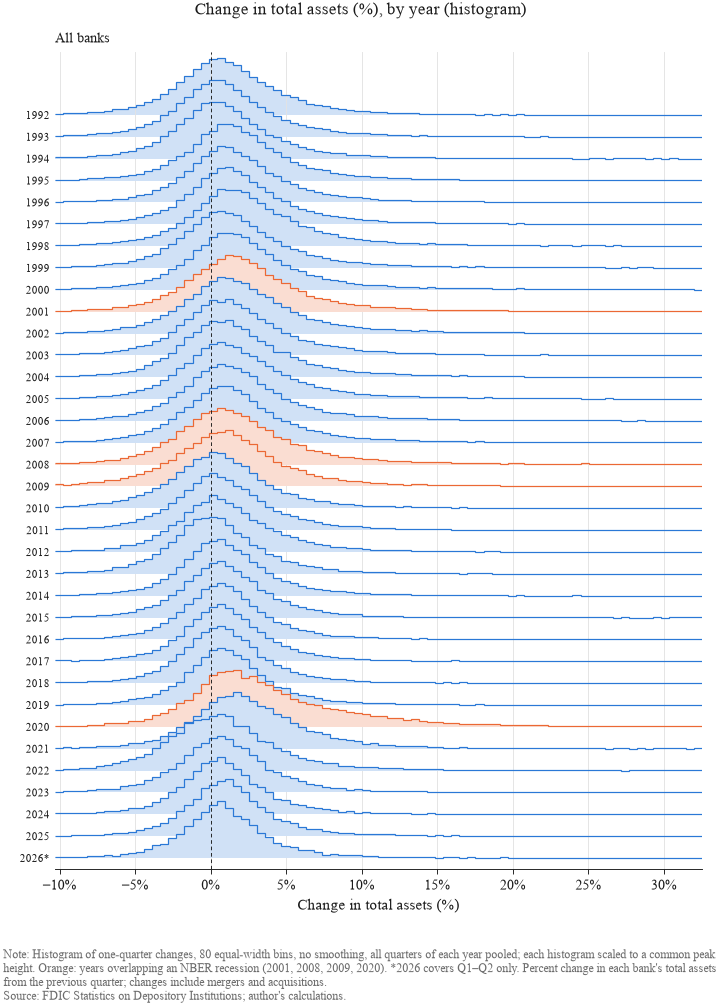

saved output/figures/quintiles/ridgeline_hist_equity_ratio.pdf, .png and _bare.pdf


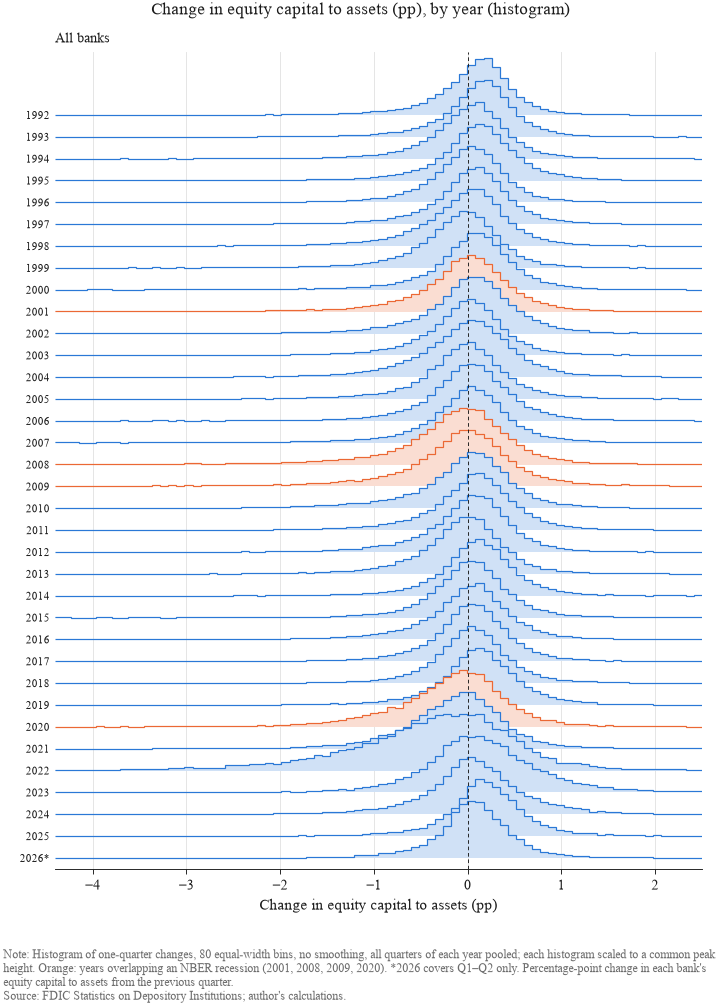

saved output/figures/quintiles/ridgeline_hist_roa.pdf, .png and _bare.pdf


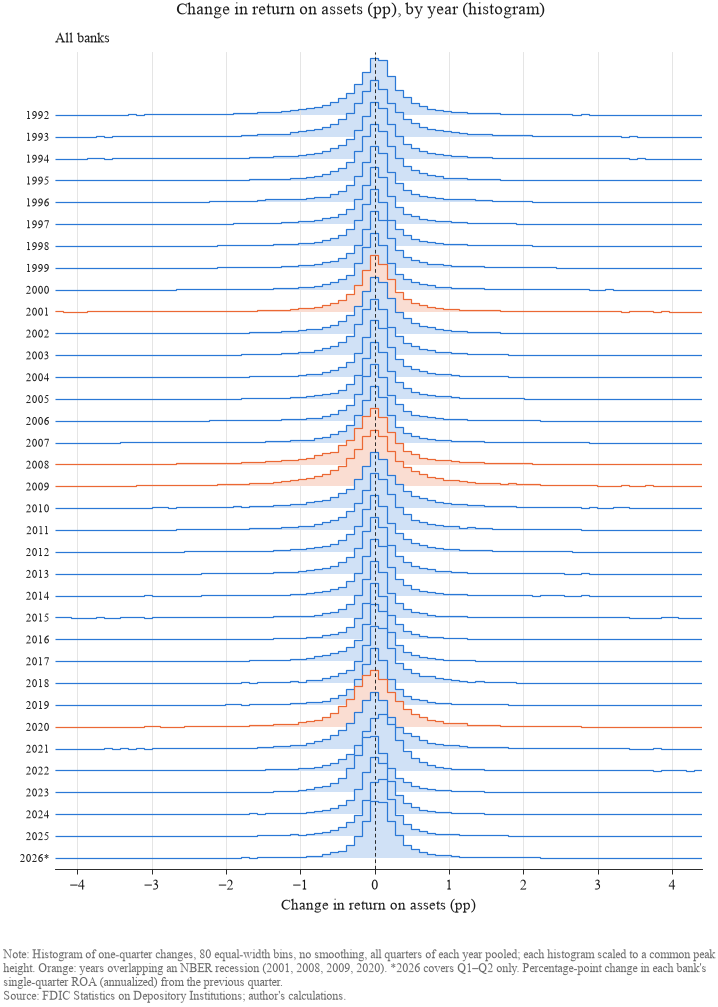

saved output/figures/quintiles/ridgeline_hist_nim.pdf, .png and _bare.pdf


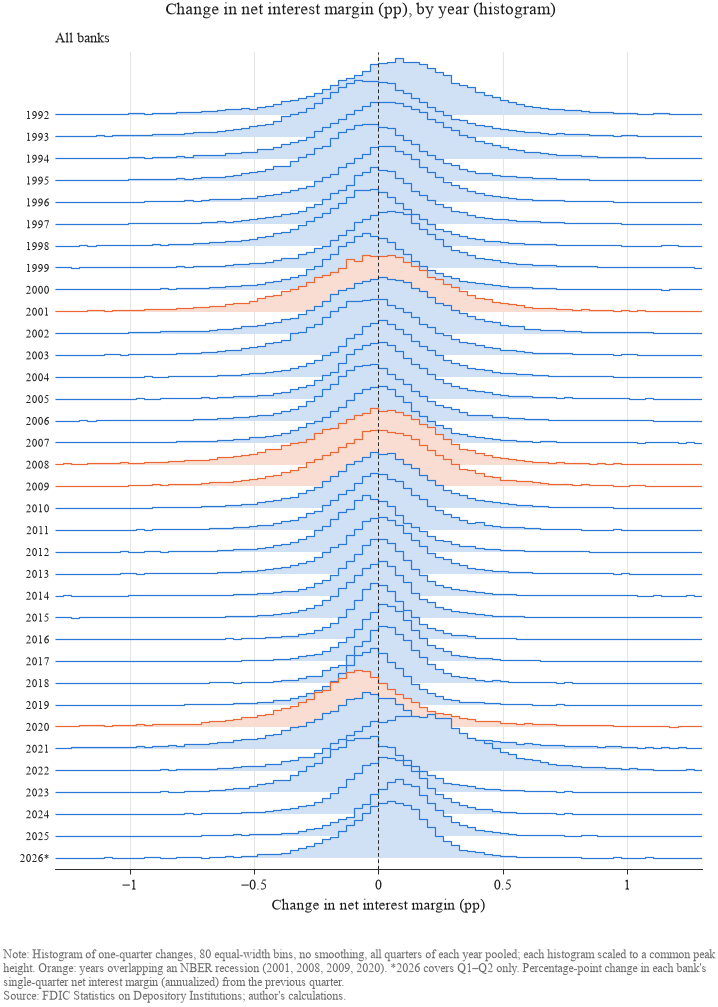

In [15]:
def ridgeline_hist(var, rows=slice(None), group_label="All banks"):
    lo, hi = KDE_RANGE[var]
    sub = chg.loc[rows]
    years = sorted(sub["date"].dt.year.unique())
    step, height = 1.0, 2.6
    fig, ax = plt.subplots(figsize=(WIDTH, 8.6))
    for i, year in enumerate(years):
        edges, dens = hist_density(sub.loc[sub["date"].dt.year == year, f"{var}_chg"], lo, hi, HIST_BINS_RIDGE)
        base = -i * step
        top = base + dens / dens.max() * height
        color = SERIES[1] if year in REC_YEARS else SERIES[0]
        ax.stairs(top, edges, baseline=base, fill=True, color="white", lw=0, zorder=2 * i + 1)
        ax.stairs(top, edges, baseline=base, fill=True, color=color, alpha=0.22, lw=0, zorder=2 * i + 1)
        ax.stairs(top, edges, baseline=None, color=color, lw=0.8, zorder=2 * i + 2)
    ax.set_yticks([-i * step for i in range(len(years))])
    ax.set_yticklabels([str(y) + ("*" if y == years[-1] and y == 2026 else "") for y in years], fontsize=7.5)
    ax.tick_params(axis="y", length=0)
    ax.set_ylim(-(len(years) - 1) * step - 0.5, height + 0.3)
    ax.set_xlim(lo, hi)
    ax.axvline(0, color=INK, lw=0.6, ls=(0, (4, 3)), zorder=200)
    ax.xaxis.set_major_formatter(fmt_for(var))
    ax.grid(True, axis="x", color=GRID, lw=0.6)
    ax.grid(False, axis="y")
    ax.spines["left"].set_visible(False)
    ax.set_xlabel(ALL_VARS[var])
    ax.set_title(group_label, loc="left", fontsize=9)
    fig.suptitle(ALL_VARS[var] + ", by year (histogram)", fontsize=11, gid="title")
    fig.tight_layout()
    add_note(fig, f"Note: Histogram of one-quarter changes, {HIST_BINS_RIDGE} equal-width bins, no smoothing, all "
                  "quarters of each year pooled; each histogram scaled to a common peak height. Orange: years "
                  "overlapping an NBER recession (2001, 2008, 2009, 2020). *2026 covers Q1–Q2 only. "
                  + VAR_NOTES[var] + SOURCE)
    return fig


for var in CORE_VARS:
    fig = ridgeline_hist(var)
    save(fig, f"ridgeline_hist_{var}")
    plt.show()


## Dispersion and skewness over time, by quintile

Two quantile-based summaries of each quarter's distribution, one line per size quintile:

- **Interquartile range** $q_{75} - q_{25}$: spread of the middle half.
- **Kelley skewness** $(q_{90} + q_{10} - 2q_{50}) / (q_{90} - q_{10})$: tail asymmetry, bounded in $[-1, 1]$; negative means a longer lower tail.

Both are smoothed with a centered four-quarter moving average, which also removes the Q4 seasonality in single-quarter flow ratios.

saved output/figures/quintiles/quintile_dispersion_assets.pdf, .png and _bare.pdf


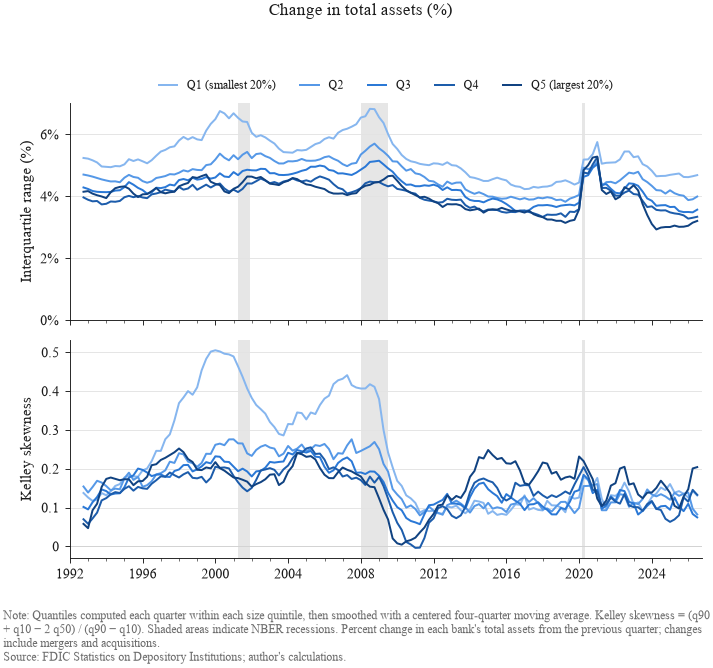

saved output/figures/quintiles/quintile_dispersion_equity_ratio.pdf, .png and _bare.pdf


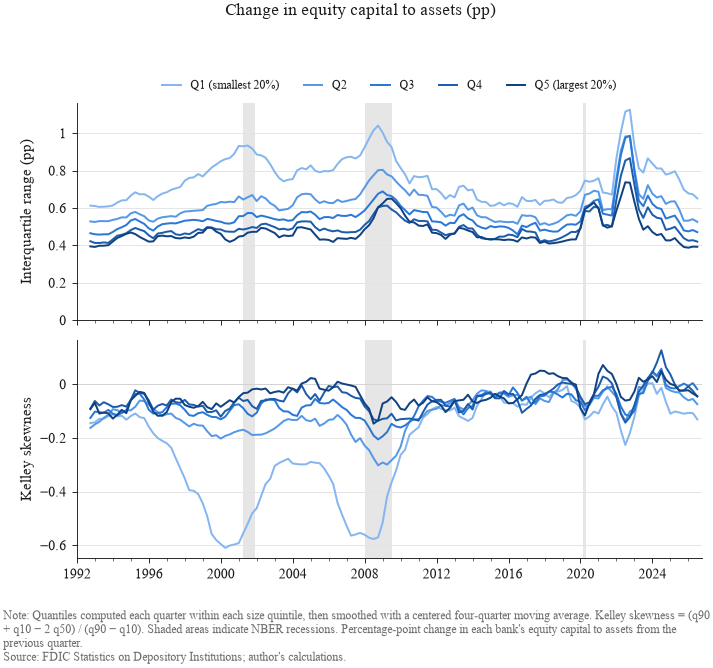

saved output/figures/quintiles/quintile_dispersion_roa.pdf, .png and _bare.pdf


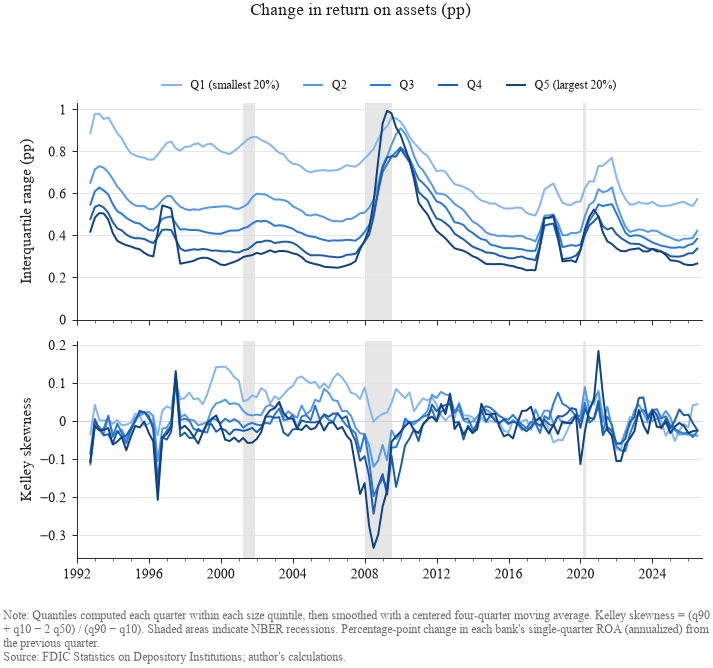

saved output/figures/quintiles/quintile_dispersion_nim.pdf, .png and _bare.pdf


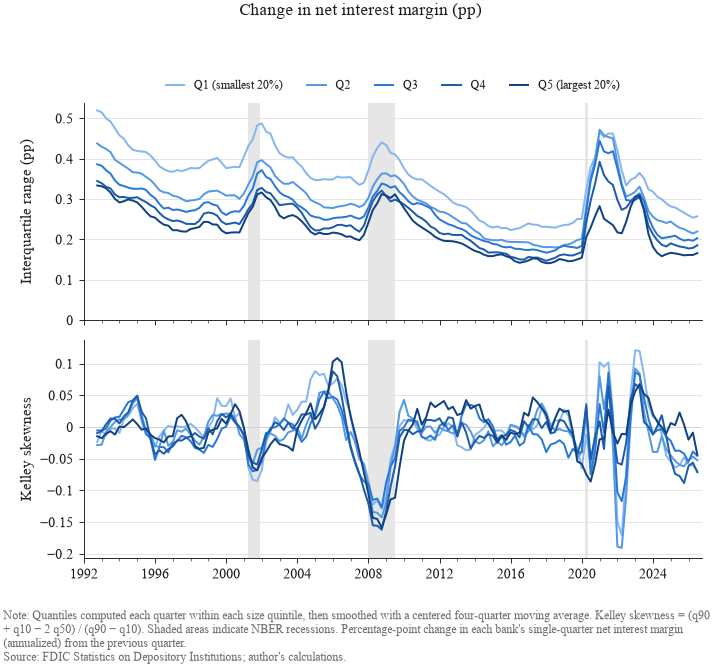

In [16]:
def quantile_stats(var):
    d = {qi: dist.loc[qi, f"{var}_chg"] for qi in QUINTILES}
    iqr = pd.DataFrame({qi: x[0.75] - x[0.25] for qi, x in d.items()})
    kelley = pd.DataFrame({qi: (x[0.90] + x[0.10] - 2 * x[0.50]) / (x[0.90] - x[0.10]) for qi, x in d.items()})
    return iqr, kelley


def dispersion_figure(var):
    iqr, kelley = quantile_stats(var)
    smooth = lambda s: s.rolling(4, center=True, min_periods=3).mean()
    fig, axes = plt.subplots(2, 1, figsize=(WIDTH, 5.2), sharex=True)
    for ax, stat, ylabel in [(axes[0], iqr, f"Interquartile range ({unit_for(var).strip()})"),
                             (axes[1], kelley, "Kelley skewness")]:
        shade_recessions(ax)
        for qi, color in zip(QUINTILES, QUINTILE_COLORS):
            ax.plot(stat.index, smooth(stat[qi]), color=color, lw=1.3, label=Q_LABELS[qi])
        ax.set_ylabel(ylabel)
        format_time_axis(ax)
    axes[0].set_ylim(0, None)
    axes[0].yaxis.set_major_formatter(fmt_for(var))
    axes[1].axhline(0, color=INK, lw=0.6, zorder=1)
    axes[1].yaxis.set_major_formatter(signed)
    axes[0].legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncols=5, fontsize=8, handlelength=1.5)
    fig.suptitle(ALL_VARS[var], fontsize=11, y=1.04, gid="title")
    fig.align_ylabels(axes)
    fig.tight_layout(h_pad=0.8)
    add_note(fig, "Note: Quantiles computed each quarter within each size quintile, then smoothed with a centered "
                  "four-quarter moving average. Kelley skewness = (q90 + q10 \u2212 2 q50) / (q90 \u2212 q10). "
                  "Shaded areas indicate NBER recessions. " + VAR_NOTES[var] + SOURCE)
    return fig


for var in CORE_VARS:
    fig = dispersion_figure(var)
    save(fig, f"quintile_dispersion_{var}")
    plt.show()

## Which parts of the distribution move with the cycle?

For each size quintile and each percentile $p = 5, 10, \dots, 95$, regress that quarter's $p$-th percentile of the change on year-over-year real GDP growth:

$$q_{p,t} = a_p + b_p \, g^{GDP}_t + e_{p,t}.$$

The slope $b_p$ is how many units the $p$-th percentile moves when GDP growth is one percentage point higher. A flat line means the whole distribution shifts together; a line that is steeper on the left means the lower tail is more cyclical than the median (the pattern the sinh-arcsinh model's skewness equation is meant to capture). This is purely descriptive: GDP growth is not an exogenous shock, and the bands show $\pm 2$ Newey–West (4-lag) standard errors.

In [17]:
gdp = pd.read_csv(PROCESSED / "1992-2026_RealGDP.csv", parse_dates=["observation_date"])
gdp = gdp.set_index(gdp["observation_date"].dt.to_period("Q"))["GDPC1"]
gdp_growth = (gdp.pct_change(4) * 100).rename("gdp_yoy")

SENS_Q = np.round(np.arange(0.05, 0.951, 0.05), 2)
sens_dist = chg.groupby(["quintile", "date"])[[f"{v}_chg" for v in CORE_VARS]].quantile(SENS_Q).unstack()


def ols_newey_west(y, x, lags=4):
    X = np.column_stack([np.ones_like(x), x])
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    u = y - X @ beta
    Xu = X * u[:, None]
    S = Xu.T @ Xu
    for L in range(1, lags + 1):
        w = 1 - L / (lags + 1)
        G = Xu[L:].T @ Xu[:-L]
        S += w * (G + G.T)
    V = XtX_inv @ S @ XtX_inv
    return beta[1], np.sqrt(V[1, 1])


rows = []
for (qi, var) in [(qi, v) for qi in QUINTILES for v in CORE_VARS]:
    d = sens_dist.loc[qi, f"{var}_chg"]
    g = gdp_growth.reindex(d.index.to_period("Q")).to_numpy()
    for p in SENS_Q:
        y = d[p].to_numpy()
        ok = np.isfinite(y) & np.isfinite(g)
        b, se = ols_newey_west(y[ok], g[ok])
        rows.append({"quintile": qi, "variable": var, "percentile": p * 100, "slope": b, "se": se})
sensitivity = pd.DataFrame(rows)
sensitivity.pivot_table(index=["variable", "quintile"], columns="percentile", values="slope")[[10.0, 50.0, 90.0]].round(3)

percentile              10.0   50.0   90.0
variable     quintile                     
assets       1        -0.058 -0.118 -0.054
             2        -0.063 -0.139 -0.273
             3        -0.061 -0.135 -0.223
             4        -0.045 -0.136 -0.244
             5         0.019 -0.107 -0.149
equity_ratio 1         0.026  0.011  0.000
             2         0.050  0.012 -0.002
             3         0.032  0.011 -0.001
             4         0.033  0.012 -0.000
             5         0.040  0.014 -0.008
nim          1         0.001  0.005  0.011
             2         0.005  0.004 -0.000
             3         0.008  0.004 -0.001
             4         0.011  0.003 -0.004
             5         0.011  0.003 -0.001
roa          1         0.013  0.002 -0.016
             2         0.032 -0.000 -0.037
             3         0.045  0.000 -0.039
             4         0.058  0.000 -0.048
             5         0.090  0.001 -0.090

saved output/figures/quintiles/quintile_gdp_sensitivity.pdf, .png and _bare.pdf


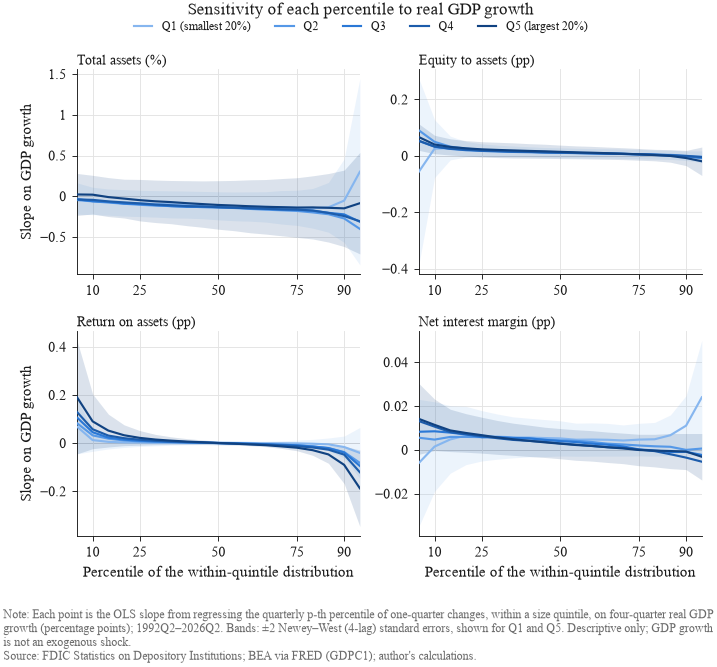

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(WIDTH, 5.4))
for ax, var in zip(axes.flat, CORE_VARS):
    ax.axhline(0, color=INK, lw=0.6, zorder=1)
    for qi, color in zip(QUINTILES, QUINTILE_COLORS):
        s = sensitivity[(sensitivity["variable"] == var) & (sensitivity["quintile"] == qi)]
        if qi in (1, 5):  # uncertainty bands for the two extreme groups only, to keep the panel legible
            ax.fill_between(s["percentile"], s["slope"] - 2 * s["se"], s["slope"] + 2 * s["se"],
                            color=color, alpha=0.15, lw=0, zorder=2)
        ax.plot(s["percentile"], s["slope"], color=color, lw=1.4, label=Q_LABELS[qi], zorder=3 + qi)
    ax.set_title(SHORT_NAMES[var] + f" ({unit_for(var).strip()})", loc="left", fontsize=9, pad=3)
    ax.set_xlim(5, 95)
    ax.set_xticks([10, 25, 50, 75, 90])
    ax.yaxis.set_major_formatter(signed)
    ax.grid(True, axis="x", color=GRID, lw=0.6)
for ax in axes[1]:
    ax.set_xlabel("Percentile of the within-quintile distribution")
for ax in axes[:, 0]:
    ax.set_ylabel("Slope on GDP growth")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.tight_layout(h_pad=1.2, w_pad=1.0, rect=(0, 0, 1, 0.94))
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.93), ncols=5, fontsize=8, handlelength=1.5)
fig.suptitle("Sensitivity of each percentile to real GDP growth", fontsize=11, y=1.0, gid="title")
add_note(fig, "Note: Each point is the OLS slope from regressing the quarterly p-th percentile of one-quarter changes, "
              "within a size quintile, on four-quarter real GDP growth (percentage points); 1992Q2\u20132026Q2. Bands: "
              "\u00b12 Newey\u2013West (4-lag) standard errors, shown for Q1 and Q5. Descriptive only; GDP growth is "
              "not an exogenous shock.\nSource: FDIC Statistics on Depository Institutions; BEA via FRED (GDPC1); "
              "author's calculations.")
save(fig, "quintile_gdp_sensitivity")
plt.show()

## Summary table

Median, IQR and Kelley skewness computed each quarter within each size quintile, then averaged over expansion and recession quarters. Written to `output/tables/quintile_summary.tex` (a `tabular` only, for `\input` inside a `table` environment) and `output/tables/quintile_summary.csv`.

In [19]:
rows = []
for var in CORE_VARS:
    iqr, kelley = quantile_stats(var)
    for qi in QUINTILES:
        stats = pd.DataFrame({"median": dist.loc[qi, (f"{var}_chg", 0.50)], "iqr": iqr[qi], "kelley": kelley[qi]})
        regime = np.where(stats.index.map(rec_by_date), "recession", "expansion")
        for reg, s in stats.groupby(regime):
            rows.append({"variable": var, "quintile": qi, "regime": reg, "quarters": len(s), **s.mean().to_dict()})
summary = pd.DataFrame(rows).set_index(["variable", "quintile", "regime"])
summary.to_csv(TABLES / "quintile_summary.csv")

TEX_LABELS = {"assets": "Total assets (\\%)", "equity_ratio": "Equity to assets (pp)",
              "roa": "Return on assets (pp)", "nim": "Net interest margin (pp)"}
cell = lambda v: f"{round(v, 2) or 0.0:.2f}".replace("-", "$-$")
wide = summary[["median", "iqr", "kelley"]].unstack("regime")
lines = []
for var in CORE_VARS:
    lines.append(rf"\multicolumn{{7}}{{l}}{{\textit{{{TEX_LABELS[var]}}}}} \\")
    for qi in QUINTILES:
        r = wide.loc[(var, qi)]
        cells = [cell(r[(stat, reg)]) for stat in ("median", "iqr", "kelley") for reg in ("expansion", "recession")]
        lines.append(rf"\quad Q{qi} & " + " & ".join(cells) + r" \\")
    lines.append(r"\addlinespace")
tex = (r"\begin{tabular}{@{}lcccccc@{}}" "\n" r"\toprule" "\n"
       r" & \multicolumn{2}{c}{Median} & \multicolumn{2}{c}{IQR} & \multicolumn{2}{c}{Kelley skewness} \\" "\n"
       r"\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(l){6-7}" "\n"
       r"Size quintile & Exp. & Rec. & Exp. & Rec. & Exp. & Rec. \\" "\n" r"\midrule" "\n"
       + "\n".join(lines[:-1]) + "\n" r"\bottomrule" "\n" r"\end{tabular}" "\n")
(TABLES / "quintile_summary.tex").write_text(tex, encoding="utf-8")
print("wrote output/tables/quintile_summary.tex and .csv")
summary.round(3)

wrote output/tables/quintile_summary.tex and .csv


quarters  median    iqr  kelley
variable     quintile regime                                    
assets       1        expansion       126   0.914  5.218   0.214
                      recession        11   2.011  6.271   0.324
             2        expansion       126   1.047  4.578   0.162
                      recession        11   2.160  5.478   0.230
             3        expansion       126   1.117  4.246   0.150
                      recession        11   2.236  5.045   0.184
             4        expansion       126   1.174  3.959   0.142
                      recession        11   2.282  4.662   0.160
             5        expansion       126   1.273  3.929   0.167
                      recession        11   2.271  4.871   0.149
equity_ratio 1        expansion       126  -0.001  0.741  -0.207
                      recession        11  -0.150  0.919  -0.410
             2        expansion       126   0.021  0.606  -0.096
                      recession        11  -0.116  0.745  -0.227
             3        expansion       126   0.030  0.545  -0.069
                      recession        11  -0.094  0.647  -0.141
             4        expansion       126   0.038  0.490  -0.051
                      recession        11  -0.094  0.585  -0.112
             5        expansion       126   0.043  0.461  -0.038
                      recession        11  -0.106  0.599  -0.074
roa          1        expansion       126   0.007  0.707   0.030
                      recession        11  -0.007  0.826   0.076
             2        expansion       126   0.008  0.522   0.007
                      recession        11  -0.016  0.632  -0.000
             3        expansion       126   0.004  0.445  -0.005
                      recession        11  -0.019  0.564  -0.046
             4        expansion       126   0.004  0.381  -0.013
                      recession        11  -0.026  0.540  -0.080
             5        expansion       126   0.005  0.347  -0.019
                      recession        11  -0.052  0.634  -0.130
nim          1        expansion       126   0.002  0.343   0.002
                      recession        11  -0.047  0.436  -0.066
             2        expansion       126   0.002  0.290  -0.010
                      recession        11  -0.028  0.369  -0.038
             3        expansion       126   0.002  0.263  -0.011
                      recession        11  -0.026  0.348  -0.044
             4        expansion       126  -0.000  0.238  -0.009
                      recession        11  -0.020  0.313  -0.056
             5        expansion       126  -0.005  0.218   0.004
                      recession        11  -0.022  0.298  -0.098